In [ ]:
import os

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng, SeedSequence
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy.optimize import root_scalar
from scipy.stats import norm
from scipy.integrate import quad, quad_vec
from scipy.special import log_ndtr
from functools import partial
from matplotlib.gridspec import GridSpec
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
import time

def vectorized_convert_to_binary(x: np.ndarray, N: int) -> np.ndarray:
    """
    Fully vectorized conversion from integer pairs
    to Ising binary vectors (-1, 1).
    """
    num_samples = x.shape[0]
    num_bits_per_int = N // 2

    powers_of_2 = 2 ** np.arange(num_bits_per_int - 1, -1, -1, dtype=np.uint32)
    
    col0_bits = (x[:, 0, None] & powers_of_2) // powers_of_2
    col1_bits = (x[:, 1, None] & powers_of_2) // powers_of_2

    bin_var = np.hstack((col0_bits, col1_bits)).astype(np.int8)
    ising_var = 2 * bin_var - 1

    return ising_var

def define_perfect_perceptron(N = 20):
    """
    Initialize the weight array for the perfect Perceptron.
    """
    positive_part = 2 ** np.arange((N/2) -1, -1, -1)
    return np.concatenate((positive_part, -positive_part))
  

class Perceptron:
  def __init__(self, N=20, J=None, seed=None):
    self.seed = seed
    self.rng = np.random.default_rng(seed)
    self.N = N

    if J is None:
      self.J = self.rng.normal(0, 1, self.N)
    else:
      self.J = J

    self.evolution_J = []

  def _sign_activation(self, x):
    x = np.asarray(x)
    return np.where(x > 0, 1, -1)

  def predict(self, x_binary):
    """Generate predictions using the fitted model weights."""
    return self._sign_activation(np.dot(x_binary, self.J)) 

  def evaluate(self, x_binary, y):
    """Calculate the mean classification error."""
    y_pred = self.predict(x_binary)
    y = np.atleast_1d(y)
    return np.mean(y_pred != y)

  def fit_perceptron(self, x_binary, y, epochs=5000):
    """
    Fit the model on training data with correct learning logic.
    """
    # Save initial state
    self.evolution_J.append(self.J.copy())

    for epoch in range(epochs):
        updates_in_epoch = 0

        combined_data = list(zip(x_binary, y))
        self.rng.shuffle(combined_data)

        for xi, yi in combined_data:
            yi_pred = self.predict(xi.reshape(1, -1))

            if yi_pred[0] != yi:
                updates_in_epoch += 1

                self.J += (yi * xi) / np.sqrt(self.N)

        self.evolution_J.append(self.J.copy())

        if updates_in_epoch == 0 and epoch > 0:
            # print(f"Convergence reached at epoch {epoch + 1}.")
            return self.J.copy()

    print(f"Training completed after {epochs} epoche (max epoche reached).")
    return self.J.copy()


  def fit_noise(self, x_binary, y, sigma2=50, epochs=5000):
    """
    Fit the model on training data with added Gaussian noise.
    """
    # Save initial state
    self.evolution_J.append(self.J.copy())

    for epoch in range(epochs):
        updates_in_epoch = 0

        combined_data = list(zip(x_binary, y))
        self.rng.shuffle(combined_data)

        for xi, yi in combined_data:
            yi_pred = self.predict(xi.reshape(1, -1))

            if yi_pred[0] != yi:
                updates_in_epoch += 1
                r_vector = self.rng.normal(0, np.sqrt(sigma2), size=self.N)
                self.J += (1 + r_vector)*(yi * xi) / np.sqrt(self.N)


        self.evolution_J.append(self.J.copy())

        if updates_in_epoch == 0 and epoch > 0:
            return self.J.copy()

    print(f"Noisy training completed after {epochs} epoche (max epoche reached).")
    return self.J.copy()
  
  def fit_hebb(self, x_binary, y):
    self.J = 0
    self.J = np.sum(x_binary * y.reshape(-1, 1), axis=0)
    return self.J.copy()
  
class SyntheticDataGenerator:
  def __init__(self, N=20, seed=None, teacher_perceptron=None):
    self.N = N
    if seed is None:
      self.rng = np.random.default_rng()
    else:
      self.rng = np.random.default_rng(seed)
    
    if teacher_perceptron is None:
      self.teacher = Perceptron(N=N, seed=seed)
    else:
      self.teacher = teacher_perceptron

  def generate_data_generic_teacher(self, P):
    """
    Generate a complete dataset (x, y) of P samples.
    
    Shape X: (P, N)
    
    Shape y: (P,)
    """
    x_binary = self.rng.choice([-1, 1], size=(P, self.teacher.N))

    y = self.teacher.predict(x_binary)

    return x_binary, y  
  
  def generate_data(self, P):
    """
    Generate a complete dataset (x, y) of P samples,
    ensuring no pair (a, b) has a == b.
    """
    max_val = 2**(self.N//2)

    x = self.rng.integers(max_val, size=(P, 2))

    duplicate_mask = (x[:, 0] == x[:, 1])

    while np.any(duplicate_mask):
      num_duplicates = np.sum(duplicate_mask)  
      # Regenerate only the second value
      x[duplicate_mask, 1] = self.rng.integers(max_val, size=num_duplicates) 
      # Update the duplicates mask
      duplicate_mask = (x[:, 0] == x[:, 1])

    x_binary = vectorized_convert_to_binary(x, self.N)

    y = self.teacher.predict(x_binary)

    return x_binary, y  

In [3]:
S = SyntheticDataGenerator()
X, y = S.generate_data(P=2000)
print(X.shape, y.shape)

(2000, 20) (2000,)


In [15]:
# ==============================================================================
#     MATHEMATICAL AND THEORETICAL DEFINITIONS (ANNEALED)
# Pure functions implementing theory. No class or state dependencies.
# ==============================================================================

def parametric_alphas_annealed(eps):
    """Calculate alpha(eps) for annealed theory parametrically."""
    safe_eps = np.clip(np.asarray(eps), 1e-9, 0.5 - 1e-9)
    return np.pi * (1 - safe_eps) / (np.tan(np.pi * safe_eps) + 1e-9)

def f1_annealed(eps, alpha):
    """First iterative map for annealed theory."""
    return 1 - alpha * np.tan(np.pi * eps) / np.pi

def f2_annealed(eps, alpha):
    """Second iterative map for annealed theory."""
    return np.arctan((np.pi * (1 - eps)) / alpha) / np.pi


# ==============================================================================
#     MATHEMATICAL AND THEORETICAL DEFINITIONS (QUENCHED)
# Pure functions implementing theory. No class or state dependencies.
# ==============================================================================

def I_R(R):
    """Calculate the integral I(R) for a single R value."""
    if R < 0 or R >= 1: return np.nan
    def integrand(v, R_val):
        log_H = log_ndtr(np.sqrt(R_val) * v)
        return np.exp(-0.5 * (1 + R_val) * v**2 - log_H) / np.sqrt(2 * np.pi)
    result, _ = quad(integrand, -np.inf, np.inf, args=(R,))
    return result

def I_R_vec(R_array):
    """Vectorized version of I_R that preserves input shape."""
    original_shape = R_array.shape
    R_flat = R_array.flatten() # Work on a flattened array

    valid_mask = (R_flat >= 0) & (R_flat < 1)
    results_flat = np.full_like(R_flat, np.nan, dtype=float)

    if np.any(valid_mask):
        valid_R = R_flat[valid_mask]
        res_quad, _ = quad_vec(
            lambda v, r: np.exp(-0.5 * (1 + r) * v**2 - log_ndtr(np.sqrt(r) * v)),
            -np.inf, np.inf, args=(valid_R,)
        )
        results_flat[valid_mask] = res_quad / np.sqrt(2 * np.pi)

    # Reshape result to original input shape
    return results_flat.reshape(original_shape)

def f1_quenched(R, alpha):
  """Function f1 handling alpha as both scalar and array."""
  R = np.asarray(R)
  # alpha può essere uno scalare o un array, il broadcasting gestirà entrambi i casi

  I_val = I_R_vec(R)

  # Calcoliamo il risultato direttamente. Se R, alpha o I_val sono NaN,
  # il risultato sarà NaN, il che è corretto.
  return (alpha / np.pi) * np.sqrt(1 - R) * I_val

def f2_quenched(R, alpha):
  """Function f2 handling alpha as both scalar and array."""
  R = np.asarray(R)
  alpha = np.asarray(alpha) # Convertire in array per ndim

  I_val = I_R_vec(R)

  # Il denominatore è il punto critico
  denominator = alpha**2 * I_val**2

  # Condizione per un calcolo valido
  valid_condition = (denominator > 1e-18) & (R >= 0) & (R < 1)

  # Calcola il rapporto solo dove la condizione è valida, altrimenti metti NaN
  ratio = np.divide(
      np.pi**2 * R**2,
      denominator,
      out=np.full_like(R, np.nan),
      where=valid_condition
  )

  return 1 - ratio

def parametric_solver_quenched(R_values):
    """Calculate alpha given a series of R values (fixed point)."""
    R_values = np.asarray(R_values)
    mask = (R_values > 0) & (R_values < 1)
    alphas = np.full_like(R_values, np.nan)
    if np.any(mask):
        valid_R = R_values[mask]
        lhs = (np.pi * valid_R) / np.sqrt(1 - valid_R)
        rhs = I_R_vec(valid_R)
        alphas[mask] = lhs / rhs
    return alphas


# ==============================================================================
#     GENERAL NUMERICAL PROCEDURES
# Functions for numerical analysis that can be reused.
# ==============================================================================

def vectorized_iterative_procedure(alphas, x_0, a, f, max_epochs=2000, tol=1e-8):
    """
    Calculate the evolution of an iterative map for an array of `alphas`.
    Returns the evolution history matrix.
    """
    alphas = np.asarray(alphas)
    num_alphas = len(alphas)
    old_x = np.full(num_alphas, float(x_0))
    history = np.zeros((max_epochs, num_alphas))

    for epoch in range(max_epochs):
        new_x = (1 - a) * old_x + a * f(old_x, alphas)
        history[epoch, :] = new_x

        if np.all(np.abs(new_x - old_x) < tol):
            print(f"Convergence reached at epoch {epoch + 1}.")
            history[epoch+1:, :] = new_x
            return history[:epoch + 1]

        old_x = new_x

    print(f"Warning: Max epochs ({max_epochs}) reached.")
    return history

def evolution_vs_a_procedure(alpha, x_0, a_values, f, max_epochs=200):
    """Calculate evolution for a fixed alpha and various `a` values."""
    a_values = np.asarray(a_values)
    num_a = len(a_values)
    old_x = np.full(num_a, float(x_0))
    history = np.zeros((max_epochs, num_a))

    for epoch in range(max_epochs):
        f_val = f(old_x, alpha)
        new_x = (1 - a_values) * old_x + a_values * f_val
        history[epoch, :] = new_x
        old_x = new_x

    return history

def numerical_derivative(f, x, alpha, h=1e-6):
    """Calculate the numerical derivative of f(x, alpha) with respect to x."""
    return (f(x + h, alpha) - f(x - h, alpha)) / (2 * h)

def hybrid_iterative_procedure(
    alphas,
    eps_0,
    a,
    f1,
    f2,
    crossover_alpha,
    max_epochs=2000,
    tol=1e-8
):
    """
    Execute a hybrid iterative procedure.

    Uses f1 for alpha <= crossover_alpha and f2 for alpha > crossover_alpha.

    Args:
        alphas (np.array): Array of alpha values.
        eps_0 (float): Starting point for iteration.
        a (float): Relaxation parameter.
        f1 (callable): Iterative function for small alpha.
        f2 (callable): Iterative function for large alpha.
        crossover_alpha (float): Alpha value at which to switch from f1 to f2.
        max_epochs (int): Maximum number of iterations.
        tol (float): Tolerance for convergence.

    Returns:
        np.array: Array of fixed points found for each alpha.
    """
    alphas = np.asarray(alphas)

    # 1. Definiamo la funzione ibrida 'f_hybrid'
    def f_hybrid(eps_array, alpha_array):
        # Inizializziamo l'output con NaN
        results = np.full_like(eps_array, np.nan)

        # Maschera per decidere quale funzione usare
        mask_f1 = (alpha_array <= crossover_alpha)
        mask_f2 = (alpha_array > crossover_alpha)

        # Applica f1 dove la maschera è vera
        if np.any(mask_f1):
            results[mask_f1] = f1(eps_array[mask_f1], alpha_array[mask_f1])

        # Applica f2 dove la maschera è vera
        if np.any(mask_f2):
            results[mask_f2] = f2(eps_array[mask_f2], alpha_array[mask_f2])

        return results

    # 2. Esegui la procedura vettorizzata con la funzione ibrida
    print(f"Running hybrid procedure with crossover at alpha = {crossover_alpha}...")
    evolution_matrix = vectorized_iterative_procedure(
        alphas,
        eps_0,
        a,
        f_hybrid,
        max_epochs,
        tol
    )

    # 3. Estrai e restituisci l'ultimo valore (il punto fisso) per ogni alpha
    fixed_points = evolution_matrix[-1, :]
    return fixed_points

# ==============================================================================
#     VISUALIZATION FUNCTIONS
# Dedicated plotting functions, separated from computation logic.
# ==============================================================================

def compare_dynamics(f1, f2, alpha, x_0, a_values, max_epochs, interval=[0.001, 0.999], is_epsilon=False, save_figure=True):
    """Execute and plot convergence dynamics for f1 and f2."""
    print("--- Computing Convergence Dynamics ---")
    evo1 = evolution_vs_a_procedure(alpha, x_0, a_values, f1, max_epochs)
    evo2 = evolution_vs_a_procedure(alpha, x_0, a_values, f2, max_epochs)

    print("--- Plotting Dynamics ---")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    colors = plt.cm.viridis(np.linspace(0, 1, len(a_values)))

    for ax, evo, f, name in zip(axes, [evo1, evo2], [f1, f2], ["f_1", "f_2"]):
        try:
            pf = root_scalar(lambda x: x - f(x, alpha), x0=x_0, bracket=interval).root
            ax.axhline(pf, color='black', ls='--', label=f'Fixed point ≈ {pf:.3f}')
        except ValueError:
            print(f"No fixed point found for {name} in the interval.")

        for i, a_val in enumerate(a_values):
            trajectory = np.concatenate(([x_0], evo[:, i]))
            ax.plot(trajectory, label=f'a = {a_val}', color=colors[i], lw=2.5)

        ax.set_title(f'Dynamics for Function ${name}$', fontsize=16)
        ax.set_xlabel('Epoch (i)', fontsize=14)
        ax.legend()
        ax.set_ylim(interval)
        ax.grid(True, ls=':', alpha=0.7)

    if is_epsilon:
        axes[0].set_ylabel(r'Value of $\epsilon_i$', fontsize=14)
    else:
        axes[0].set_ylabel(r'Value of $R_i$', fontsize=14)
    fig.suptitle(f'Dynamics Comparison for $\\alpha={alpha}$ e $x_0={x_0}$', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    if save_figure:
        filename = f"compare_dynamics_x0_{x_0}_alpha_{alpha}.png"
        print(f"\nSaving figure to: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()


def plot_results_annealed(
    f_map=f2_annealed,
    a_fixed=0.9,
    x0_fixed=0.5,
    max_epochs=5000,
    save_figure=False
):
    """
    Generate a plot comparing the theoretical parametric curve (Annealed)
    with fixed points calculated via iterative dynamics.

    Args:
        f_map (callable): The map function to use for iteration (es. f2_annealed).
        a_fixed (float): Fixed value of relaxation parameter 'a'.
        x0_fixed (float): Initial value for iteration.
        max_epochs (int): Maximum number of epochs for convergence.
        save_figure (bool): If True, save the plot to file.
    """
    print("\n--- Executing Comparison Plot (Annealed) ---")

    # --- 1. Calcolo Curva Teoria Parametrica ---
    print("Computing theoretical parametric curve...")
    eps_parametric = np.linspace(1e-9, 0.5 - 1e-9, 500)
    alpha_parametric = parametric_alphas_annealed(eps_parametric)

    # --- 2. Calcolo Punti Fissi da Mappa Iterativa ---
    print(f"Computing fixed points from iterative map (using {f_map.__name__})...")
    alphas_for_map = np.linspace(0.01, 10, 100)
    evolution_matrix = vectorized_iterative_procedure(
        alphas=alphas_for_map,
        x_0=x0_fixed,
        a=a_fixed,
        f=f_map,
        max_epochs=max_epochs
    )
    eps_from_map = evolution_matrix[-1, :] if evolution_matrix.shape[0] > 0 else np.full_like(alphas_for_map, np.nan)

    # --- 3. Creazione del Grafico ---
    print("--- Computation complete. Starting plotting. ---")
    fig, ax = plt.subplots(figsize=(14, 9))

    # Plotta Curva Teoria Parametrica
    ax.plot(
        alpha_parametric,
        eps_parametric,
        color='black',
        linestyle='--',
        linewidth=3,
        label='Annealed Theory (Parametric)'
    )

    # Plotta Punti Fissi Trovati
    ax.plot(
        alphas_for_map,
        eps_from_map,
        'o',
        markersize=8,
        color='limegreen',
        markeredgecolor='black',
        label=f'Fixed Points from Dynamics ({f_map.__name__}, a={a_fixed})'
    )

    # --- 4. Personalizzazione Grafico ---
    ax.set_title(r"Learning Curve (Annealed) - $\epsilon^*$ vs $\alpha$", fontsize=20, pad=15)
    ax.set_xlabel(r"$\alpha = p/N$", fontsize=16)
    ax.set_ylabel(r"$\epsilon^*$", fontsize=16)
    ax.legend(fontsize=14)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax.set_xlim(left=0, right=10)
    ax.set_ylim(bottom=-0.02, top=0.55)
    ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()

    if save_figure:
        filename = "annealed_theory_vs_dynamics.png"
        print(f"\nSaving figure to: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

def plot_results_quenched(
    a_fixed=0.5,
    r_zero_fixed=0.5,
    crossover_alpha=2.0,
    max_epochs_fixed=5000,
    plot_in_epsilon=True,
    save_figure=False
    ):
    """
    Generate a plot comparing the theoretical parametric curve (quenched)
    with fixed points calculated via hybrid iterative procedure.

    Allows visualization of results in terms of R(alpha) or epsilon(alpha).

    Args:
        plot_in_epsilon (bool): If True, the y-axis shows error epsilon.
                                If False (default), shows overlap R.
    """
    # --- 1. Parametri per la Simulazione ---

    alphas_for_fixed_point = np.linspace(0.1, 8, 100)

    # --- 2. Calcolo dei Punti Fissi tramite Procedura Ibrida ---
    # La procedura calcola sempre l'overlap R
    fixed_point_R = hybrid_iterative_procedure(
        alphas=alphas_for_fixed_point,
        eps_0=r_zero_fixed,
        a=a_fixed,
        f1=f1_quenched,
        f2=f2_quenched,
        crossover_alpha=crossover_alpha,
        max_epochs=max_epochs_fixed
    )

    # --- 3. Generazione della Curva Parametrica Teorica ---
    print("\n--- Computing Theoretical Parametric Curve ---")
    r_values_parametric = np.linspace(0.001, 0.999, 500)
    alpha_values_parametric = parametric_solver_quenched(r_values_parametric)

    # --- 4. Conversione a Epsilon (se richiesta) e Impostazione Etichette ---
    if plot_in_epsilon:
        # Conversione dei dati
        y_values_parametric = (1 / np.pi) * np.arccos(r_values_parametric)
        y_values_fixed_point = (1 / np.pi) * np.arccos(fixed_point_R)

        # Impostazione etichette e limiti per epsilon
        title = r"Learning Curve (Quenched) - $\epsilon^*$ vs $\alpha$"
        ylabel = r"$\epsilon^*$"
        ylim = (-0.02, 0.52)
    else:
        # I dati rimangono in termini di R
        y_values_parametric = r_values_parametric
        y_values_fixed_point = fixed_point_R

        # Impostazione etichette e limiti per R
        title = r"Learning Curve (Quenched) - $R^*$ vs $\alpha$"
        ylabel = r"$R^*$"
        ylim = (-0.05, 1.05)

    # --- 5. Creazione del Grafico ---
    print("--- Computation complete. Starting plotting. ---")
    fig, ax = plt.subplots(figsize=(14, 9))

    # Plotta la curva parametrica teorica
    ax.plot(
        alpha_values_parametric,
        y_values_parametric, # <-- Usa i valori y corretti (R o epsilon)
        color='purple',
        linestyle='--',
        linewidth=2.5,
        label='Quenched Theory (Parametric)'
    )

    # Plotta i punti fissi trovati iterativamente
    ax.plot(
        alphas_for_fixed_point,
        y_values_fixed_point, # <-- Usa i valori y corretti (R o epsilon)
        'o',
        markersize=7,
        color='limegreen',
        markeredgecolor='black',
        label=f'Fixed Points from Dynamics Ibrida (a={a_fixed})'
    )

    ax.axvline(x=crossover_alpha, color='red', linestyle=':', linewidth=2, label=f'Crossover $\\alpha_c = {crossover_alpha}$')

    # --- 6. Personalizzazione del Grafico ---
    ax.set_title(title, fontsize=20, pad=15)
    ax.set_xlabel(r"$\alpha = P/N$", fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.legend(fontsize=14)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)

    ax.set_xlim(left=0, right=8)
    ax.set_ylim(bottom=ylim[0], top=ylim[1])
    ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()
    
    if save_figure:
        filename = "quenched_comparison_plot_final.png"
        print(f"\nSaving figure to: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

def plot_advanced_comparison_(exp_results, save_figure=True):
    """
    Plot the complete comparison between experimental data and theories.
    Include:
    1. Experimental data for N=20 and N=40.
    2. Annealed theory (both parametric and from iterative map).
    3. Quenched theory (both parametric and from hybrid map).
    """
    print("\n--- Executing Comparison Plot Completo ---")
    res = exp_results

    # --- 1. Preparazione Dati Sperimentali ---
    alpha_20 = np.array(res['train_sizes_20']) / 20
    sem_20 = res['error_stds_20'] / np.sqrt(res.get('runs_num', 1000))

    alpha_40 = np.array(res['train_sizes_40']) / 40
    sem_40 = res['error_stds_40'] / np.sqrt(res.get('runs_num', 1000))

    # --- 2. Calcolo Teorie Annealed ---
    print("Computing Annealed theories...")
    # Curva parametrica
    eps_param_annealed = np.linspace(1e-9, 0.5 - 1e-9, 500)
    alpha_param_annealed = parametric_alphas_annealed(eps_param_annealed)
    # Punti fissi da mappa iterativa (es. f2)
    alphas_for_annealed_map = np.linspace(0.01, 15, 100)
    evo_matrix_annealed = vectorized_iterative_procedure(
        alphas=alphas_for_annealed_map,
        x_0=0.5,
        a=0.9,
        f=f2_annealed, # Usiamo f2 per l'annealed
        max_epochs=5000
    )
    eps_from_annealed_map = evo_matrix_annealed[-1, :] if evo_matrix_annealed.shape[0] > 0 else np.full_like(alphas_for_annealed_map, np.nan)


    # --- 3. Calcolo Teorie Quenched ---
    print("Computing Quenched theories...")
    # Curva parametrica (esatta)
    r_param_quenched = np.linspace(0.001, 0.999, 500)
    alpha_param_quenched = parametric_solver_quenched(r_param_quenched)
    eps_param_quenched = (1 / np.pi) * np.arccos(r_param_quenched)

    # Punti fissi da procedura ibrida (validazione numerica)
    A_FIXED_HYBRID = 0.5
    R_ZERO_HYBRID = 0.5
    CROSSOVER_ALPHA_HYBRID = 2.0
    alphas_for_hybrid_map = np.linspace(0.1, 15, 100)

    fixed_points_R_quenched = hybrid_iterative_procedure(
        alphas=alphas_for_hybrid_map,
        eps_0=R_ZERO_HYBRID,
        a=A_FIXED_HYBRID,
        f1=f1_quenched,
        f2=f2_quenched,
        crossover_alpha=CROSSOVER_ALPHA_HYBRID
    )
    eps_from_hybrid_map = (1 / np.pi) * np.arccos(fixed_points_R_quenched)

    print("--- Theoretical computations complete. Starting plotting. ---")

    # --- 4. Creazione del Grafico ---
    fig, ax = plt.subplots(figsize=(16, 10))

    # --- GRUPPO ANNEALED ---
    ax.plot(alpha_param_annealed, eps_param_annealed, color='deepskyblue', linestyle=':', lw=3,
            label='Annealed (Teoria Parametrica)')
    ax.plot(alphas_for_annealed_map, eps_from_annealed_map, 'P', markersize=8, color='cyan',
            alpha=0.8, markeredgecolor='black', linestyle='None',
            label=r'Annealed (Punti Fissi da $f_2$)')

    # --- GRUPPO QUENCHED ---
    ax.plot(alpha_param_quenched, eps_param_quenched, color='black', linestyle='--', lw=3,
            label='Quenched (Teoria Parametrica)')
    ax.plot(alphas_for_hybrid_map, eps_from_hybrid_map, 'x', markersize=8, color='limegreen',
            label=f'Quenched (Punti Fissi da Ibrido)')

    # --- GRUPPO SPERIMENTALE ---
    ax.errorbar(alpha_20, res['error_means_20'], yerr=sem_20, fmt='o', markersize=8, capsize=5,
                label='Experimental N=20 (SEM)', color='royalblue', zorder=10)
    ax.errorbar(alpha_40, res['error_means_40'], yerr=sem_40, fmt='s', markersize=8, capsize=5,
                label='Experimental N=40 (SEM)', color='red', zorder=10)

    # --- 5. Personalizzazione Grafico ---
    ax.set_title(r"Complete Comparison: Experimental Data vs Theories", fontsize=20, pad=15)
    ax.set_xlabel(r"$\alpha = p/N$", fontsize=16)
    ax.set_ylabel(r"$\langle \epsilon \rangle$ (Mean Generalization Error)", fontsize=16)

    # Migliora la legenda
    handles, labels = ax.get_legend_handles_labels()
    # Ordine personalizzato per la legenda per una migliore leggibilità
    order = [4, 5, 2, 3, 0, 1]
    ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], fontsize=13, ncol=2)

    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax.set_xlim(left=0, right=15)
    ax.set_ylim(bottom=-0.02, top=0.55)
    ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()

    if save_figure:
        filename = "master_comparison_plot_final.png"
        print(f"\nSaving figure to: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

def plot_convergence_analysis(
    f1,
    f2,
    parametric_solver,
    alpha_range=(0.1, 10),
    a_range=(0, 2),
    x_range=(0.001, 0.999),
    grid_resolution=(100, 100),
    a_highlight=None, # NUOVO PARAMETRO: valore di 'a' da evidenziare
    labels={
        'title': 'Convergence Analysis of Iterative Dynamics',
        'x_label': r'$\alpha$',
        'y_label': r'$a$ (relaxation parameter)',
        'var_name': 'R'
    },
    save_figure=True
):
    """
    Analizza e visualizza la stabilità di due mappe iterative f1 e f2.
    Genera due heatmap e un grafico comparativo dell'efficienza.
    Permette di evidenziare l'efficienza per un valore specifico di 'a'.
    """
    print("--- Starting Convergence Analysis ---")

    # 1. Creazione della griglia di parametri
    alpha_vals = np.linspace(alpha_range[0], alpha_range[1], grid_resolution[0])
    a_vals = np.linspace(a_range[0], a_range[1], grid_resolution[1])
    ALPHA_grid, A_grid = np.meshgrid(alpha_vals, a_vals, indexing='ij')

    # 2. Pre-computing fixed points x*(alpha)
    print("Pre-computing fixed points...")
    # Valori di R per calcolare alpha(R)
    x_solver_grid = np.linspace(x_range[0], x_range[1], 200)
    # Valori di alpha(R) calcolati in modo parametrico
    alpha_solver_grid = parametric_solver(x_solver_grid)
    # Seleziono solo i valori non nan di alpha
    valid_indices = ~np.isnan(alpha_solver_grid)
    # Ordino i valori di alpha per interpolare e
    # visualizzare R(alpha) con alpha crescente
    sorted_indices = np.argsort(alpha_solver_grid[valid_indices])
    # Interpolo i valori, calcolo R(alpha) (alpha(R) monotono posso invertire senza problemi)
    x_star_func = np.interp(
        alpha_vals,
        alpha_solver_grid[valid_indices][sorted_indices],
        x_solver_grid[valid_indices][sorted_indices]
    )

    # 3. Calcolo delle derivate e del fattore di convergenza
    print("Calcolo delle derivate numeriche sulla griglia...")
    f1_prime_1d = numerical_derivative(f1, x_star_func, alpha_vals)
    f2_prime_1d = numerical_derivative(f2, x_star_func, alpha_vals)

    f1_prime_grid = np.tile(f1_prime_1d, (grid_resolution[1], 1)).T
    g1_prime_grid = (1 - A_grid) + A_grid * f1_prime_grid
    C1 = np.abs(g1_prime_grid)

    f2_prime_grid = np.tile(f2_prime_1d, (grid_resolution[1], 1)).T
    g2_prime_grid = (1 - A_grid) + A_grid * f2_prime_grid
    C2 = np.abs(g2_prime_grid)

    # 4. Calcolo della curva a_ottimale
    a_opt1 = 1 / (1 - f1_prime_1d)
    a_opt2 = 1 / (1 - f2_prime_1d)

    print("--- Analisi Completata. Inizio Plotting. ---")

    # 5. Visualizzazione
    fig = plt.figure(figsize=(22, 16))
    gs = GridSpec(2, 2, height_ratios=[3, 2], hspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
    ax_comp = fig.add_subplot(gs[1, :])

    levels = [0, 0.2, 0.5, 0.8, 1.0]
    contour_colors = 'white'

    # --- Heatmap per f1 (con highlight di 'a' se specificato) ---
    im1 = ax1.imshow(C1.T, extent=[alpha_range[0], alpha_range[1], a_range[0], a_range[1]], origin='lower', aspect='auto', cmap='viridis_r', vmin=0, vmax=2)
    cs1 = ax1.contour(alpha_vals, a_vals, C1.T, levels=levels, colors=contour_colors, linewidths=1.5)
    ax1.clabel(cs1, inline=True, fontsize=10, fmt='%.1f')
    ax1.plot(alpha_vals, a_opt1, color='red', linestyle='--', label=r'$a_{opt}$')
    if a_highlight is not None:
        ax1.axhline(y=a_highlight, color='cyan', linestyle=':', linewidth=2, label=f'$a = {a_highlight}$')
    ax1.set_title(r"Fattore di Convergenza $|g'(R^*)|$ per $f_1$", fontsize=18)
    ax1.set_xlabel(labels['x_label'], fontsize=14)
    ax1.set_ylabel(labels['y_label'], fontsize=14)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.5)

    # --- Heatmap per f2 (con highlight di 'a' se specificato) ---
    im2 = ax2.imshow(C2.T, extent=[alpha_range[0], alpha_range[1], a_range[0], a_range[1]], origin='lower', aspect='auto', cmap='viridis_r', vmin=0, vmax=2)
    cs2 = ax2.contour(alpha_vals, a_vals, C2.T, levels=levels, colors=contour_colors, linewidths=1.5)
    ax2.clabel(cs2, inline=True, fontsize=10, fmt='%.1f')
    ax2.plot(alpha_vals, a_opt2, color='red', linestyle='--', label=r'$a_{opt}$')
    if a_highlight is not None:
        ax2.axhline(y=a_highlight, color='cyan', linestyle=':', linewidth=2, label=f'$a = {a_highlight}$')
    ax2.set_title(r"Fattore di Convergenza $|g'(R^*)|$ per $f_2$", fontsize=18)
    ax2.set_xlabel(labels['x_label'], fontsize=14)
    plt.setp(ax2.get_yticklabels(), visible=False)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.5)

    # --- Colorbar ---
    cbar = fig.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.02)
    cbar.set_label(r"Fattore di Riduzione dell'Errore $|g'(R^*)|$", fontsize=14, rotation=270, labelpad=25)

    # --- Grafico Comparativo di Efficienza (MODIFICATO) ---
    ax_comp.axhline(y=1.0, color='red', linestyle='--', label='Limite di convergenza')
    ax_comp.fill_between(alpha_vals, 1.0, 10, color='red', alpha=0.1, label='Regione di Divergenza')
    ax_comp.fill_between(alpha_vals, 0, 1.0, color='green', alpha=0.1, label='Regione di Convergenza')

    # Efficienza per a=1 (riferimento)
    g1_prime_a1 = np.abs(f1_prime_1d)
    g2_prime_a1 = np.abs(f2_prime_1d)
    ax_comp.plot(alpha_vals, g1_prime_a1, label=r"$|g'|$ per $f_1$ con $a=1$", color='royalblue', linestyle=':', linewidth=2)
    ax_comp.plot(alpha_vals, g2_prime_a1, label=r"$|g'|$ per $f_2$ con $a=1$", color='darkorange', linestyle=':', linewidth=2)

    # Efficienza per a_highlight (se specificato)
    if a_highlight is not None:
        g1_prime_highlight = np.abs((1 - a_highlight) + a_highlight * f1_prime_1d)
        g2_prime_highlight = np.abs((1 - a_highlight) + a_highlight * f2_prime_1d)
        ax_comp.plot(alpha_vals, g1_prime_highlight, label=fr"$|g'|$ per $f_1$ con $a={a_highlight}$", color='royalblue', linewidth=2.5)
        ax_comp.plot(alpha_vals, g2_prime_highlight, label=fr"$|g'|$ per $f_2$ con $a={a_highlight}$", color='darkorange', linewidth=2.5)
        ax_comp.set_title(f"Efficienza Comparata dei Metodi (con focus su $a={a_highlight}$)", fontsize=18)
    else:
        ax_comp.set_title("Efficienza Comparata dei Metodi ($a=1$)", fontsize=18)

    ax_comp.set_xlabel(labels['x_label'], fontsize=14)
    ax_comp.set_ylabel(r"Fattore di Convergenza $|g'(R^*)|$", fontsize=14)
    ax_comp.set_xlim(alpha_range)
    ax_comp.set_ylim(0, 2.0)
    ax_comp.legend(fontsize=12)
    ax_comp.grid(True, linestyle=':', alpha=0.7)

    fig.suptitle(labels['title'], fontsize=24, y=0.98)
    
    if save_figure:
        filename = 'convergence_comparison.png'
        print(f"\nSaving figure to: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        
    plt.show()


In [3]:
def hebb_gen_error(alpha: np.ndarray) -> np.ndarray:
    return np.arccos(np.sqrt((2*alpha) / (2*alpha + np.pi))) / np.pi

def hebb_train_error(alpha: np.ndarray) -> np.ndarray:
    """
    Calculates the theoretical training error for the Hebbian learning rule.

    This function is designed to be vectorized over the input `alpha`.
    """
    
    integrand = lambda x, alpha: np.exp(-0.5 * x**2 + log_ndtr(-1/np.sqrt(alpha) - np.sqrt(2 * alpha / np.pi) * x))
    integral, _ = quad_vec(integrand, 0, np.inf, args=(alpha,))
        
    return np.sqrt(2/np.pi)*integral
    

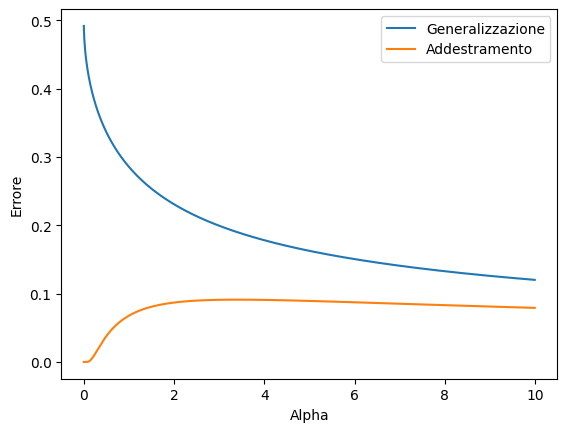

In [40]:
alphas = np.arange(0.001, 10, 0.01)

hebb_gen_error(alphas)
hebb_train_error(alphas)

plt.plot(alphas, hebb_gen_error(alphas), label='Generalizzazione')
plt.plot(alphas, hebb_train_error(alphas), label='Addestramento')
plt.xlabel('Alpha')
plt.ylabel('Errore')
plt.legend()
plt.show()

In [31]:
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes

def run_single_perceptron_noise(N: int, P: int, x_val: np.ndarray, y_val: np.ndarray, sigma2: float, seed: int, teacher_perceptron: Perceptron) -> float:
    """
    Esegue UNA singola run di addestramento e valutazione.
    Questa funzione è definita a livello di modulo (top-level) per essere
    efficientemente parallelizzabile con `joblib` e `multiprocessing`.
    """
    # Generatori e perceptron con lo stesso seed (per coerenza interna)
    data_generator = SyntheticDataGenerator(seed=seed, N=N, teacher_perceptron=teacher_perceptron)
    student_perceptron = Perceptron(N=N, seed=seed)

    # Genera dati di training unici per questa run
    x_train, y_train = data_generator.generate_data(P=P)

    # Addestra il modello
    student_perceptron.fit_noise(x_train, y_train, sigma2=sigma2)

    # Valuta l'errore sui dati di validazione comuni
    error = student_perceptron.evaluate(x_val, y_val)
    return error

def run_single_perceptron_zero_noise(N: int, P: int, seed: int, test_size: int) -> float:
    """
    Esegue UNA singola run di addestramento e valutazione.
    Questa funzione è definita a livello di modulo (top-level) per essere
    efficientemente parallelizzabile con `joblib` e `multiprocessing`.
    """
    ss = SeedSequence(seed)
    dataset_seed, student_seed = ss.spawn(2)
    
    data_generator = SyntheticDataGenerator(N=N,seed=dataset_seed)
    student_perceptron = Perceptron(N=N, seed=student_seed)
    
    # Genera dati di training unici per questa run
    x_train, y_train = data_generator.generate_data_generic_teacher(P=P)
    x_val, y_val = data_generator.generate_data_generic_teacher(P=test_size)
    
    # Addestra il modello
    student_perceptron.fit_perceptron(x_train, y_train)

    # Valuta l'errore sui dati di validazione comuni
    error = student_perceptron.evaluate(x_val, y_val)
    return error

def run_single_hebb(N: int, P: int, seed: int, test_size: int) -> tuple:
    """
    Esegue UNA singola run di addestramento e valutazione.
    Questa funzione è definita a livello di modulo (top-level) per essere
    efficientemente parallelizzabile con `joblib` e `multiprocessing`.
    
    return train_error, gen_error
    """
    ss = SeedSequence(seed)
    
    dataset_seed, student_seed = ss.spawn(2)
    
    data_generator = SyntheticDataGenerator(N=N,seed=dataset_seed)
    student_perceptron = Perceptron(N=N, seed=student_seed)
    
    # Genera dati di training unici per questa run
    x_train, y_train = data_generator.generate_data_generic_teacher(P=P)
    x_val, y_val = data_generator.generate_data_generic_teacher(P=test_size)
    
    # Addestra il modello
    student_perceptron.fit_hebb(x_train, y_train)
    
    # Valuta l'errore sui dati di validazione comuni
    train_error = student_perceptron.evaluate(x_train, y_train)
    gen_error = student_perceptron.evaluate(x_val, y_val)
    return train_error, gen_error

class Experiment:
  def __init__(self, name="Esperimento Perceptrone"):
    """
    Inizializza l'esperimento.
    """
    self.name = name
    self.results = {}

  def simulation_perceptron_noise(self, train_sizes: list[int], test_size: int, runs_num: int, sigma2: float, N: int, master_seed: int = 123456):
    print(f"--- Inizio simulazione perceptron noise parallela per N = {N} ---")
    error_means = []
    error_stds = []

    master_rng = np.random.default_rng(master_seed)

    print(f"Generazione di {test_size} campioni di validazione per N={N}...")
    
    perfect_J = define_perfect_perceptron(N=N)
    perfect_teacher = Perceptron(N=N, J=perfect_J)
    
    data_generator_val = SyntheticDataGenerator(N=N, seed=master_rng.integers(0, 2**31 - 1), teacher_perceptron=perfect_teacher)
    x_val, y_val = data_generator_val.generate_data(P=test_size)

    for P in train_sizes:
        start_time = time.time()
        print(f"Avvio di {runs_num} run in parallelo per N={N}, P={P}...")

        # Genera semi indipendenti per ogni run
        run_seeds = master_rng.integers(0, 2**31 - 1, size=runs_num)
        
        # Esegui in parallelo con i semi specifici
        errors = Parallel(
            n_jobs=-1,
            verbose=10,
            batch_size='auto',
            pre_dispatch='2*n_jobs'
        )(
            delayed(run_single_perceptron_noise)(N, P, x_val, y_val, sigma2, seed=s, teacher_perceptron=perfect_teacher)
            for s in run_seeds
        )

        errors = np.array(errors)
        error_means.append(np.mean(errors))
        error_stds.append(np.std(errors))

        end_time = time.time()
        print(f"Completato per N={N}, P={P} in {end_time - start_time:.2f} secondi. Errore medio: {error_means[-1]:.4f} ± {error_stds[-1]:.4f}")

    return np.array(error_means), np.array(error_stds)

  def simulation_perceptron_zero_noise(self, train_sizes: list[int], test_size: int, runs_num: int, N: int, master_seed: int = 123456):
    print(f"--- Inizio simulazione perceptron noise parallela per N = {N} ---")
    error_means = []
    error_stds = []

    master_rng = np.random.default_rng(master_seed)

    print(f"Generazione di {test_size} campioni di validazione per N={N}...")
    
    for P in train_sizes:
        start_time = time.time()
        print(f"Avvio di {runs_num} run in parallelo per N={N}, P={P}...")

        # Genera semi indipendenti per ogni run
        run_seeds = master_rng.integers(0, 2**31 - 1, size=runs_num)
        
        # Esegui in parallelo con i semi specifici
        errors = Parallel(
            n_jobs=-1,
            verbose=10,
            batch_size='auto',
            pre_dispatch='2*n_jobs'
        )(
            delayed(run_single_perceptron_zero_noise)(N, P, seed=s, test_size=test_size)
            for s in run_seeds
        )

        errors = np.array(errors)
        error_means.append(np.mean(errors))
        error_stds.append(np.std(errors))

        end_time = time.time()
        print(f"Completato per N={N}, P={P} in {end_time - start_time:.2f} secondi. Errore medio: {error_means[-1]:.4f} ± {error_stds[-1]:.4f}")

    return np.array(error_means), np.array(error_stds)

  def simulation_hebb(self, train_sizes: list[int], test_size: int, runs_num: int, N: int, master_seed: int = 123456):
    print(f"--- Inizio simulazione perceptron noise parallela per N = {N} ---")
    train_error_means = []
    train_error_stds = []
    
    gen_error_means = []
    gen_error_stds = []

    master_rng = np.random.default_rng(master_seed)

    print(f"Generazione di {test_size} campioni di validazione per N={N}...")
    
    for P in train_sizes:
        start_time = time.time()
        print(f"Avvio di {runs_num} run in parallelo per N={N}, P={P}...")

        # Genera semi indipendenti per ogni run
        run_seeds = master_rng.integers(0, 2**31 - 1, size=runs_num)
        
        # Esegui in parallelo con i semi specifici
        errors = Parallel(
            n_jobs=-1,
            verbose=0,
            batch_size='auto',
            pre_dispatch='2*n_jobs'
        )(
            delayed(run_single_hebb)(N, P, seed=s, test_size=test_size)
            for s in run_seeds
        )
        train_errors , gen_errors = zip(*errors)
        
        train_errors = np.array(train_errors)
        train_error_means.append(np.mean(train_errors))
        train_error_stds.append(np.std(train_errors))
        
        gen_errors = np.array(gen_errors)
        gen_error_means.append(np.mean(gen_errors))
        gen_error_stds.append(np.std(gen_errors))

        end_time = time.time()
        print(f"Completato per N={N}, P={P} in {end_time - start_time:.2f} secondi.")
        print(f"Errore medio di train: {train_error_means[-1]:.4f} ± {train_error_stds[-1]:.4f}")
        print(f"Errore medio di generalizzazione: {gen_error_means[-1]:.4f} ± {gen_error_stds[-1]:.4f}")

    return np.array(train_error_means), np.array(train_error_stds), np.array(gen_error_means), np.array(gen_error_stds)
    
  def run_experiment_perceptron_noise(self):
    print(f"--- Esecuzione Esperimento Perceptron Random ---")
    test_size, runs_num, sigma2 = 1000, 1000, 50
    train_sizes_20 = [1, 10, 20, 50, 100, 150, 200]
    means20, stds20 = self.simulation_perceptron_noise(train_sizes_20, test_size, runs_num, sigma2, N=20)
    train_sizes_40 = [1, 2, 20, 40, 100, 200, 300]
    means40, stds40 = self.simulation_perceptron_noise(train_sizes_40, test_size, runs_num, sigma2, N=40)
    results = {
        'runs_num': runs_num,
        'train_sizes_20': train_sizes_20, 'error_means_20': means20, 'error_stds_20': stds20,
        'train_sizes_40': train_sizes_40, 'error_means_40': means40, 'error_stds_40': stds40,
    }
    self.results.update(results)
    print("\n--- Simulazioni Completate ---")
    return results

  def run_experiment_hebb(self, N):
    print(f"--- Esecuzione Esperimento Hebb ---")
    test_size, runs_num = 1000, 1000
    alpha_max = 11
    alpha_resolution = 0.2
    P_max_train = int(alpha_max*N)
    P_resolution = int(alpha_resolution*N)
    train_sizes = np.arange(1, P_max_train, P_resolution)
    train_means_hebb, train_stds_hebb, gen_means_hebb, gen_stds_hebb = self.simulation_hebb(train_sizes=train_sizes, test_size=test_size, runs_num=runs_num, N=N)
    
    results = {
        'runs_num_hebb': runs_num,
        'train_sizes_hebb': train_sizes, 'N_dimension_hebb': N, 'train_error_means_hebb': train_means_hebb, 'train_error_stds_hebb': train_stds_hebb,
        'gen_error_means_hebb': gen_means_hebb, 'gen_error_stds_hebb': gen_stds_hebb
    }
    
    self.results.update(results)
    print("\n --- Simulazioni Completate ---")
    return results

  def run_experiment_perceptron_zero_noise(self, N):
    print(f"--- Esecuzione Esperimento Hebb ---")
    test_size, runs_num = 1000, 1000
    alpha_max = 11
    alpha_resolution = 0.2
    P_max_train = int(alpha_max*N)
    P_resolution = int(alpha_resolution*N)
    train_sizes = np.arange(1, P_max_train, P_resolution)
    gen_means_perceptron_zero_noise, gen_stds_perceptron_zero_noise = self.simulation_perceptron_zero_noise(train_sizes=train_sizes, test_size=test_size, runs_num=runs_num, N=N)
    
    results = {
        'runs_num_perceptron_zero_noise': runs_num,
        'train_sizes_perceptron_zero_noise': train_sizes, 
        'N_dimension_perceptron_zero_noise': N, 
        'gen_error_perceptron_zero_noise': gen_means_perceptron_zero_noise, 
        'gen_error_stds_perceptron_zero_noise': gen_stds_perceptron_zero_noise        
    }
    
    self.results.update(results)
    print("\n --- Simulazioni Completate ---")
    return results

  def plot_hebb_results(self, results=None, save_figure=True):
    """
    Plotta le curve di errore sperimentali e teoriche per l'esperimento di Hebb.
    Genera una prima figura con training e generalization error separati.
    Genera una seconda figura con un'analisi comparativa degli errori.
    """
    print("\n--- Esecuzione Plot dei Risultati della Hebb Rule ---")
    
    # Logica per scegliere quale dizionario di risultati usare
    if results is None:
        if not self.results:
            raise RuntimeError("Nessun risultato da plottare. Esegui .run_experiment_hebb() o fornisci un dizionario 'results'.")
        res = self.results
    else:
        res = results
        
    # Verifica che i risultati provengano dall'esperimento corretto
    hebb_specific_key = 'runs_num_hebb'
    if hebb_specific_key not in res:
        raise ValueError("Attenzione, i risultati caricati non sono quelli relativi all'esperimento .run_experiment_hebb.")

    # --- Estrazione e calcolo dati ---
    train_sizes = np.array(res['train_sizes_hebb'])
    runs_num = res['runs_num_hebb']
    N_dim = res['N_dimension_hebb']
    
    alpha_exp = train_sizes / N_dim
    train_error_mean = np.array(res['train_error_means_hebb'])
    gen_error_mean = np.array(res['gen_error_means_hebb'])
    train_sem = np.array(res['train_error_stds_hebb']) / np.sqrt(runs_num)
    gen_sem = np.array(res['gen_error_stds_hebb']) / np.sqrt(runs_num)

    alpha_analytical = np.linspace(max(0.01, alpha_exp.min()), alpha_exp.max(), 400)
    train_error_analytical = hebb_train_error(alpha_analytical)
    gen_error_analytical = hebb_gen_error(alpha_analytical)

    # --- FIGURA 1: Errori Separati ---
    fig1, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 10))
    fig1.suptitle(f'Apprendimento Hebbiano: Confronto Teorico-Experimental (N={N_dim})', fontsize=20)

    # Pannello 1: Errore di Training
    ax1 = axes[0]
    ax1.errorbar(alpha_exp, train_error_mean, yerr=train_sem, fmt='o', markersize=5, capsize=4, label='Dati Sperimentali (con SEM)', color='royalblue')
    ax1.plot(alpha_analytical, train_error_analytical, '-', label='Curva Teorica', color='darkorange', linewidth=2.5)
    ax1.set_title('Errore di Training', fontsize=18)
    ax1.set_xlabel(r'$\alpha = P/N$', fontsize=18)
    ax1.set_ylabel(r'$\epsilon_{train}$', fontsize=18)
    ax1.legend(fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.set_ylim(bottom=0)
    ax1.set_xlim(left=0)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Pannello 2: Errore di Generalizzazione
    ax2 = axes[1]
    ax2.errorbar(alpha_exp, gen_error_mean, yerr=gen_sem, fmt='o', markersize=5, capsize=4, label='Dati Sperimentali (con SEM)', color='forestgreen')
    ax2.plot(alpha_analytical, gen_error_analytical, '-', label='Curva Teorica', color='crimson', linewidth=2.5)
    ax2.set_title('Errore di Generalizzazione', fontsize=18)
    ax2.set_xlabel(r'$\alpha = P/N$', fontsize=18)
    ax2.set_ylabel(r'$\epsilon_{gen}$', fontsize=18)
    ax2.legend(fontsize=16)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.set_ylim(bottom=0)
    ax2.set_xlim(left=0)
    ax2.tick_params(axis='both', which='major', labelsize=16)

    fig1.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_figure:
        filename1 = f"hebb_learning_comparison_N{N_dim}.png"
        fig1.savefig(filename1, dpi=150)
        print(f"Grafico 1 salvato come '{filename1}'")
    plt.show()

    # --- FIGURA 2: Analisi Comparativa degli Errori ---
    
    diff_exp = gen_error_mean - train_error_mean
    diff_sem = np.sqrt(gen_sem**2 + train_sem**2)
    diff_analytical = gen_error_analytical - train_error_analytical

    fig2, ax_main = plt.subplots(figsize=(18, 11))
    
    # Plot della differenza (in primo piano)
    ax_main.errorbar(alpha_exp, diff_exp, yerr=diff_sem, fmt='o', markersize=5, capsize=4, label=r'Experimental ($\epsilon_{gen} - \epsilon_{train}$)', color='purple')
    ax_main.plot(alpha_analytical, diff_analytical, '-', label=r'Teorica ($\epsilon_{gen} - \epsilon_{train}$)', color='magenta', linewidth=2.5)
    
    # Aggiunta delle curve di errore individuali (in secondo piano)
    # Errore di generalizzazione
    ax_main.errorbar(alpha_exp, gen_error_mean, yerr=gen_sem, fmt='o', markersize=4, capsize=3, label=r'Experimental ($\epsilon_{gen}$)', color='forestgreen', alpha=0.7)
    ax_main.plot(alpha_analytical, gen_error_analytical, '--', label=r'Teorica ($\epsilon_{gen}$)', color='crimson', linewidth=2)
    
    # Errore di training
    ax_main.errorbar(alpha_exp, train_error_mean, yerr=train_sem, fmt='o', markersize=4, capsize=3, label=r'Experimental ($\epsilon_{train}$)', color='royalblue', alpha=0.7)
    ax_main.plot(alpha_analytical, train_error_analytical, '--', label=r'Teorica ($\epsilon_{train}$)', color='darkorange', linewidth=2)

    ax_main.set_title(f'Analisi Comparativa degli Errori (N={N_dim})', fontsize=20)
    ax_main.set_xlabel(r'$\alpha = P/N$', fontsize=18)
    ax_main.set_ylabel('Errore', fontsize=18)
    ax_main.legend(fontsize=14) # Leggermente più piccolo per contenere tutte le etichette
    ax_main.grid(True, linestyle='--', alpha=0.6)
    ax_main.tick_params(axis='both', which='major', labelsize=16)
    ax_main.set_xlim(left=0)
    ax_main.set_ylim(bottom=0)

    fig2.tight_layout()
    if save_figure:
        filename2 = f"hebb_error_analysis_N{N_dim}.png"
        fig2.savefig(filename2, dpi=150)
        print(f"Grafico 2 salvato come '{filename2}'")
    plt.show()

  def plot_advanced_comparison(self, results=None, save_figure=True):
    """
    Plotta il confronto completo tra dati sperimentali (Perceptron, Hebb) e le teorie
    (Annealed, Quenched, Hebb, inclusi gli errori di training e la loro differenza).
    - Se `results` è None, usa `self.results`.
    - Altrimenti, usa il dizionario `results` fornito.
    """
    print("\n--- Executing Comparison Plot Completo ---")

    # --- 1. Selezione e Validazione dei Dati ---
    res = results if results is not None else self.results

    required_experiments = {
        'hebb': 'runs_num_hebb',
        'perceptron_noise': 'train_sizes_20',
        'perceptron_zero_noise': 'runs_num_perceptron_zero_noise'
    }
    missing_experiments = [name for name, key in required_experiments.items() if key not in res]
    if missing_experiments:
        raise RuntimeError(
            f"Dati incompleti. Mancano i risultati per: {', '.join(missing_experiments)}. "
            "Assicurati di aver eseguito tutte le simulazioni."
        )
    print("Tutti i set di dati necessari sono stati trovati.")

    # --- 2. Preparazione Dati Sperimentali ---
    # Perceptron con rumore (sigma > 0)
    alpha_20 = np.array(res['train_sizes_20']) / 20
    sem_gen_20 = res['error_stds_20'] / np.sqrt(res.get('runs_num', 1000))
    alpha_40 = np.array(res['train_sizes_40']) / 40
    sem_gen_40 = res['error_stds_40'] / np.sqrt(res.get('runs_num', 1000))

    # Perceptron senza rumore (sigma = 0)
    N_pzn = res['N_dimension_perceptron_zero_noise']
    alpha_pzn = np.array(res['train_sizes_perceptron_zero_noise']) / N_pzn
    gen_error_mean_pzn = res['gen_error_perceptron_zero_noise']
    sem_gen_pzn = res['gen_error_stds_perceptron_zero_noise'] / np.sqrt(res['runs_num_perceptron_zero_noise'])
    
    # Hebb (training, generalizzazione e loro differenza)
    N_hebb = res["N_dimension_hebb"]
    alpha_hebb_exp = np.array(res['train_sizes_hebb']) / N_hebb
    gen_error_mean_hebb = np.array(res['gen_error_means_hebb'])
    sem_gen_hebb = np.array(res['gen_error_stds_hebb']) / np.sqrt(res['runs_num_hebb'])
    train_error_mean_hebb = np.array(res['train_error_means_hebb'])
    sem_train_hebb = np.array(res['train_error_stds_hebb']) / np.sqrt(res['runs_num_hebb'])
    
    # Calcolo della differenza e propagazione dell'errore (SEM)
    diff_error_mean_hebb = gen_error_mean_hebb - train_error_mean_hebb
    sem_diff_hebb = np.sqrt(sem_gen_hebb**2 + sem_train_hebb**2)


    # --- 3. Calcolo Curve Teoriche ---
    print("Computing Annealed theories, Quenched e Hebb...")
    alphas_theory = np.linspace(0.01, 15, 400)
    
    # Teorie per l'errore di generalizzazione
    eps_param_annealed = np.linspace(1e-9, 0.5 - 1e-9, 500)
    alpha_param_annealed = parametric_alphas_annealed(eps_param_annealed)
    r_param_quenched = np.linspace(0.001, 0.999, 500)
    alpha_param_quenched = parametric_solver_quenched(r_param_quenched)
    eps_param_quenched = (1 / np.pi) * np.arccos(r_param_quenched)
    
    # Teorie per la regola di Hebb
    eps_hebb_gen_analytical = hebb_gen_error(alphas_theory)
    eps_hebb_train_analytical = hebb_train_error(alphas_theory)
    diff_hebb_analytical = eps_hebb_gen_analytical - eps_hebb_train_analytical

    print("--- Theoretical computations complete. Starting plotting. ---")

    # --- 4. Creazione del Grafico ---
    fig, ax = plt.subplots(figsize=(20, 13))
    
    # Plot Teorie
    ax.plot(alpha_param_quenched, eps_param_quenched, color='black', linestyle='--', lw=3, label=r'Teoria Quenched ($\epsilon_{gen}$)')
    ax.plot(alpha_param_annealed, eps_param_annealed, color='deepskyblue', linestyle=':', lw=3, label=r'Teoria Annealed ($\epsilon_{gen}$)')
    ax.plot(alphas_theory, eps_hebb_gen_analytical, color='purple', linestyle='-.', lw=3, label=r'Teoria Hebb ($\epsilon_{gen}$)')
    ax.plot(alphas_theory, eps_hebb_train_analytical, color='magenta', linestyle=':', lw=3, label=r'Teoria Hebb ($\epsilon_{train}$)')
    ax.plot(alphas_theory, diff_hebb_analytical, color='orange', linestyle='--', lw=2.5, label=r'Teoria Hebb ($\epsilon_{gen} - \epsilon_{train}$)')

    # Plot Dati Sperimentali
    label_hebb_gen = f'Experimental Hebb N={N_hebb} ' + r'($\epsilon_{gen}$)'
    label_hebb_train = f'Experimental Hebb N={N_hebb} ' + r'($\epsilon_{train}$)'
    label_hebb_diff = f'Experimental Hebb N={N_hebb} ' + r'($\epsilon_{gen} - \epsilon_{train}$)'
    label_pzn_gen = f'Experimental Perceptron N={N_pzn} ($\\sigma=0$) ' + r'($\epsilon_{gen}$)'
    
    ax.errorbar(alpha_20, res['error_means_20'], yerr=sem_gen_20, fmt='o', markersize=8, capsize=5, label=r'Experimental Perceptron N=20 ($\sigma>0, \epsilon_{gen}$)', color='royalblue', zorder=10)
    ax.errorbar(alpha_40, res['error_means_40'], yerr=sem_gen_40, fmt='s', markersize=8, capsize=5, label=r'Experimental Perceptron N=40 ($\sigma>0, \epsilon_{gen}$)', color='red', zorder=10)
    ax.errorbar(alpha_hebb_exp, gen_error_mean_hebb, yerr=sem_gen_hebb, fmt='D', markersize=8, capsize=5, label=label_hebb_gen, color='darkviolet', zorder=10)
    # Modifica: rimosso linestyle=':' per non collegare i punti
    ax.errorbar(alpha_hebb_exp, train_error_mean_hebb, yerr=sem_train_hebb, fmt='D', markerfacecolor='none', markeredgecolor='darkviolet', markersize=8, capsize=5, label=label_hebb_train, linestyle='None', zorder=9)
    # Aggiunta: nuova curva per la differenza degli errori
    ax.errorbar(alpha_hebb_exp, diff_error_mean_hebb, yerr=sem_diff_hebb, fmt='^', markersize=8, capsize=5, label=label_hebb_diff, color='darkorange', zorder=10)
    ax.errorbar(alpha_pzn, gen_error_mean_pzn, yerr=sem_gen_pzn, fmt='*', markersize=12, capsize=5, label=label_pzn_gen, color='limegreen', markeredgecolor='black', zorder=11)

    # --- 5. Personalizzazione ---
    ax.set_title(r"Complete Comparison: Experimental Data vs Theories", fontsize=22, pad=15)
    ax.set_xlabel(r"$\alpha = P/N$", fontsize=18)
    ax.set_ylabel(r"$\langle \epsilon \rangle$ (Errore Medio)", fontsize=18)
    
    # Ordine personalizzato per una legenda più leggibile
    handles, labels = ax.get_legend_handles_labels()
    # Mappatura per raggruppare le curve per tipo
    order = [
        # Perceptron
        7, 8, 6,
        # Hebb
        9, 10, 11,
        # Teorie
        0, 1, 2, 3, 4, 5
    ]
    # Filtra indici non validi se il numero di elementi è cambiato
    valid_order = [i for i in order if i < len(handles)]
    ax.legend([handles[idx] for idx in valid_order], [labels[idx] for idx in valid_order], fontsize=14, ncol=2)
    
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax.set_xlim(left=0, right=10.5)
    ax.set_ylim(bottom=-0.02, top=0.55)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    fig.tight_layout()

    if save_figure:
        filename = "master_comparison_plot_full_with_zero_noise.png"
        print(f"\nSaving figure to: {filename}")
        fig.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()


In [6]:
if __name__ == "__main__":

    try:
        num_cores = len(os.sched_getaffinity(0))
    except AttributeError:
        num_cores = os.cpu_count()
    print(f"*** Rilevati {num_cores} core CPU disponibili per la parallelizzazione. ***\n")

    experiment_runner = Experiment(name="Confronto Training N=20 e N=40")
    final_results = experiment_runner.run()

    # Stampa un riassunto dei risultati
    print("\n--- Riepilogo Risultati ---")
    print("N=20:")
    for p, mean, std in zip(final_results['train_sizes_20'], final_results['error_means_20'], final_results['error_stds_20']):
        alpha = p / 20
        print(f"  alpha = {alpha:.2f} (P={p}): errore = {mean:.4f} ± {std:.4f}")

    print("\nN=40:")
    for p, mean, std in zip(final_results['train_sizes_40'], final_results['error_means_40'], final_results['error_stds_40']):
        alpha = p / 40
        print(f"  alpha = {alpha:.2f} (P={p}): errore = {mean:.4f} ± {std:.4f}")

*** Rilevati 8 core CPU disponibili per la parallelizzazione. ***

--- Esecuzione Esperimento: Confronto Training N=20 e N=40 ---
--- Inizio simulazione parallela per N = 20 ---
Generazione di 1000 campioni di validazione per N=20...
Avvio di 1000 run in parallelo per N=20, P=1...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.16653728485107422s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.06166958808898926s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09952306747436523s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.02969050407409668s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.08968424797058105s.) Setting batch_size=32.
[Paralle

Completato per N=20, P=1 in 1.06 secondi. Errore medio: 0.4897 ± 0.0768
Avvio di 1000 run in parallelo per N=20, P=10...


[Parallel(n_jobs=-1)]: Batch computation too fast (0.03178691864013672s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09564709663391113s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.036588430404663086s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.08175539970397949s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.12362027168273926s.) Setting batch_size=32.
[Parallel(n_jobs=-1)]: Done 320 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]

Completato per N=20, P=10 in 1.07 secondi. Errore medio: 0.4148 ± 0.0724
Avvio di 1000 run in parallelo per N=20, P=20...


...

[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   11.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   12.7s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   19.7s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   25.1s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   28.1s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   31.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   34.0s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   39.2s
[Paralle

Completato per N=40, P=200 in 176.20 secondi. Errore medio: 0.1140 ± 0.0220
Avvio di 1000 run in parallelo per N=40, P=300...


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   16.3s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   20.9s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   25.3s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   31.7s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   37.9s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   42.3s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   49.3s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   57.2s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:  1.3min
[Paralle

Completato per N=40, P=300 in 418.67 secondi. Errore medio: 0.0748 ± 0.0159

--- Simulazioni Completate ---

--- Riepilogo Risultati ---
N=20:
  alpha = 0.05 (P=1): errore = 0.4897 ± 0.0768
  alpha = 0.50 (P=10): errore = 0.4148 ± 0.0724
  alpha = 1.00 (P=20): errore = 0.3409 ± 0.0638
  alpha = 2.50 (P=50): errore = 0.2043 ± 0.0456
  alpha = 5.00 (P=100): errore = 0.1116 ± 0.0292
  alpha = 7.50 (P=150): errore = 0.0743 ± 0.0221
  alpha = 10.00 (P=200): errore = 0.0537 ± 0.0170

N=40:
  alpha = 0.03 (P=1): errore = 0.4963 ± 0.0562
  alpha = 0.05 (P=2): errore = 0.4903 ± 0.0540
  alpha = 0.50 (P=20): errore = 0.4167 ± 0.0500
  alpha = 1.00 (P=40): errore = 0.3396 ± 0.0458
  alpha = 2.50 (P=100): errore = 0.2058 ± 0.0332
  alpha = 5.00 (P=200): errore = 0.1140 ± 0.0220
  alpha = 7.50 (P=300): errore = 0.0748 ± 0.0159


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  7.0min finished



--- Esecuzione Plot di Confronto Completo ---
Calcolo teorie Annealed...
Convergenza raggiunta all'epoca 9.
Calcolo teorie Quenched...
Esecuzione procedura ibrida con crossover a alpha = 2.0...
Convergenza raggiunta all'epoca 26.
--- Calcoli Teorici Completati. Inizio Plotting. ---

Salvataggio figura in: master_comparison_plot_final.png


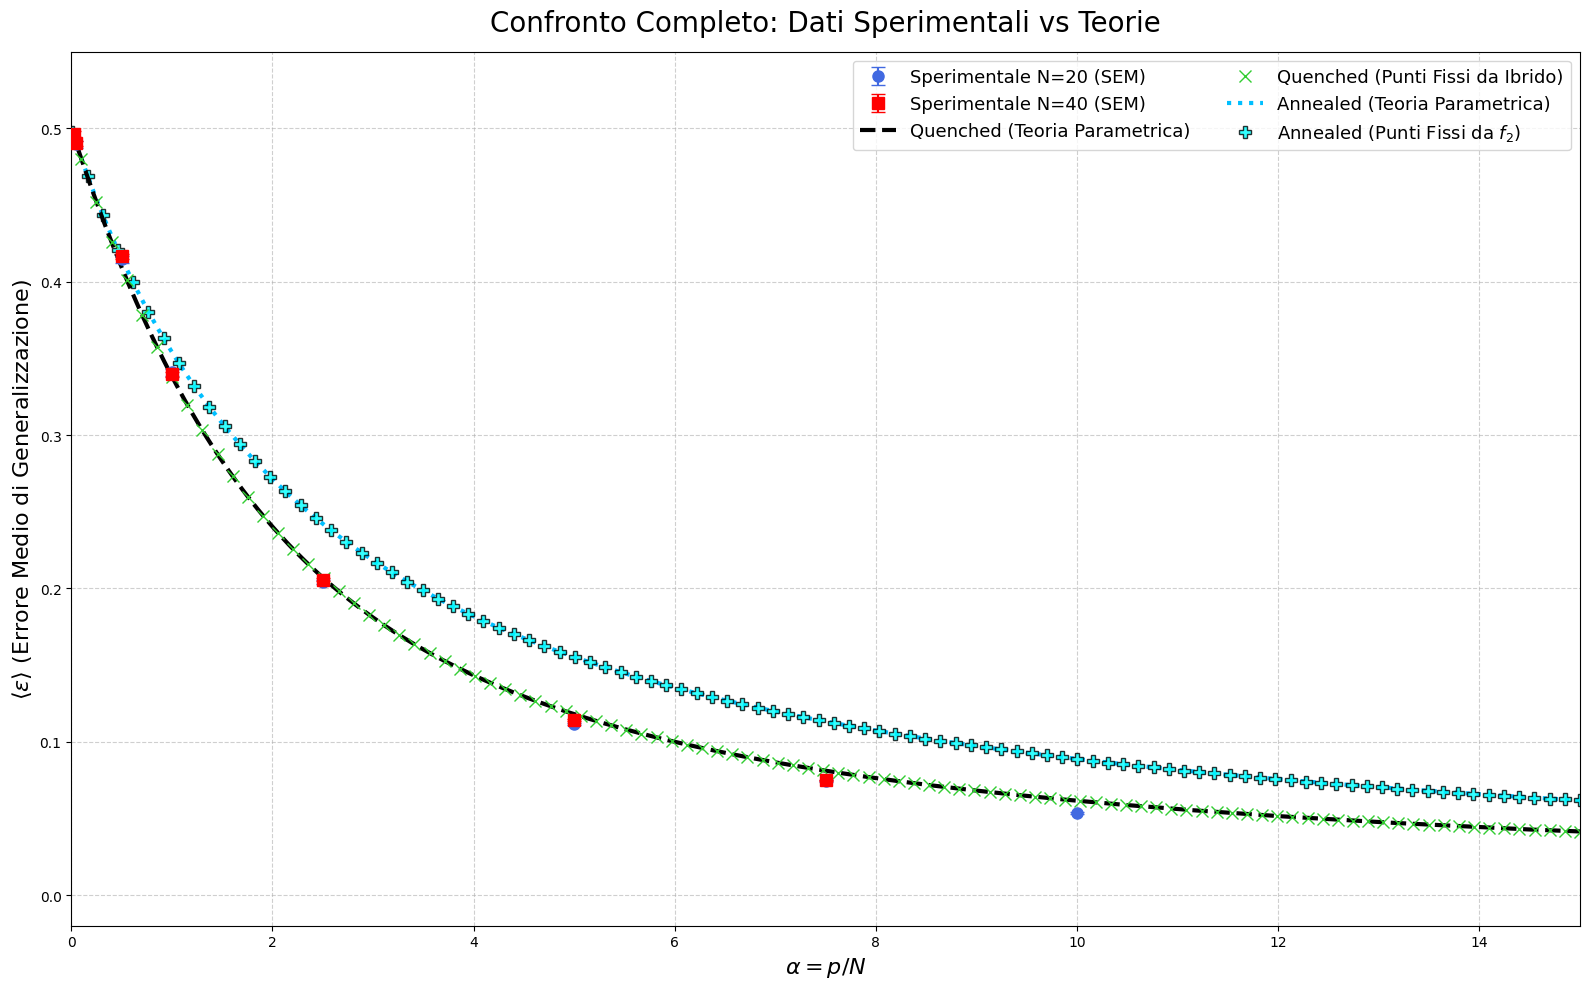

In [7]:
experiment_runner.plot_advanced_comparison()

In [6]:
if __name__ == "__main__":
    # Dimensione dello spazio per la dinamica di Hebb
    N_hebb = 50
    
    try:
        num_cores = len(os.sched_getaffinity(0))
    except AttributeError:
        num_cores = os.cpu_count()
    print(f"*** Rilevati {num_cores} core CPU disponibili per la parallelizzazione. ***\n")

    experiment_runner = Experiment(name="Confronto tra Dinamiche Annealed e Quenched e Hebb Learning Rule")
    final_results = experiment_runner.run_experiment_hebb(N=N_hebb)
    
for key, values in final_results.items():
    print(f"{key} : {values}")


*** Rilevati 8 core CPU disponibili per la parallelizzazione. ***

--- Esecuzione Esperimento Hebb ---
--- Inizio simulazione perceptron noise parallela per N = 50 ---
Generazione di 1000 campioni di validazione per N=50...
Avvio di 1000 run in parallelo per N=50, P=1...
Completato per N=50, P=1 in 2.06 secondi.
Errore medio di train: 0.0000 ± 0.0000
Errore medio di generalizzazione: 0.4631 ± 0.0318
Avvio di 1000 run in parallelo per N=50, P=11...
Completato per N=50, P=11 in 0.91 secondi.
Errore medio di train: 0.0055 ± 0.0220
Errore medio di generalizzazione: 0.3844 ± 0.0292
Avvio di 1000 run in parallelo per N=50, P=21...
Completato per N=50, P=21 in 0.92 secondi.
Errore medio di train: 0.0274 ± 0.0343
Errore medio di generalizzazione: 0.3452 ± 0.0291
Avvio di 1000 run in parallelo per N=50, P=31...
Completato per N=50, P=31 in 0.88 secondi.
Errore medio di train: 0.0457 ± 0.0334
Errore medio di generalizzazione: 0.3192 ± 0.0277
Avvio di 1000 run in parallelo per N=50, P=41...
Compl

In [7]:
if __name__ == "__main__":
    # Dimensione dello spazio per la dinamica di Hebb
    N_perc_noise = 50
    
    try:
        num_cores = len(os.sched_getaffinity(0))
    except AttributeError:
        num_cores = os.cpu_count()
    print(f"*** Rilevati {num_cores} core CPU disponibili per la parallelizzazione. ***\n")

    experiment_runner = Experiment(name="Confronto tra Dinamiche Annealed e Quenched e Hebb Learning Rule")
    final_results = experiment_runner.run_experiment_perceptron_zero_noise(N=N_perc_noise)
    
for key, values in final_results.items():
    print(f"{key} : {values}")

*** Rilevati 8 core CPU disponibili per la parallelizzazione. ***

--- Esecuzione Esperimento Hebb ---
--- Inizio simulazione perceptron noise parallela per N = 50 ---
Generazione di 1000 campioni di validazione per N=50...
Avvio di 1000 run in parallelo per N=50, P=1...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.014490127563476562s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.11658859252929688s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.04454755783081055s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.04733633995056152s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.07004404067993164s.) Setting batch_size=32.
[Parall

Completato per N=50, P=1 in 0.82 secondi. Errore medio: 0.4974 ± 0.0472
Avvio di 1000 run in parallelo per N=50, P=11...


[Parallel(n_jobs=-1)]: Batch computation too fast (0.07360196113586426s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.05626487731933594s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.10657095909118652s.) Setting batch_size=32.
[Parallel(n_jobs=-1)]: Done 320 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.07817292213439941s.) Setting batch_size=64.
[Parallel(n_jobs=-1)]: Done 560 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 779 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 824 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 875 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 926 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:

Completato per N=50, P=11 in 0.81 secondi. Errore medio: 0.4569 ± 0.0466
Avvio di 1000 run in parallelo per N=50, P=21...


...

[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.0963710392104966s.) Setting batch_size=1.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  73 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  88 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 101 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 161 tasks      | elapsed:   11.0s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 197 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done 216 tasks

Completato per N=50, P=531 in 68.08 secondi. Errore medio: 0.0464 ± 0.0098
Avvio di 1000 run in parallelo per N=50, P=541...


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   13.4s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   15.0s
[Paralle

Completato per N=50, P=541 in 71.98 secondi. Errore medio: 0.0454 ± 0.0097

 --- Simulazioni Completate ---
runs_num_perceptron_zero_noise : 1000
train_sizes_perceptron_zero_noise : [  1  11  21  31  41  51  61  71  81  91 101 111 121 131 141 151 161 171
 181 191 201 211 221 231 241 251 261 271 281 291 301 311 321 331 341 351
 361 371 381 391 401 411 421 431 441 451 461 471 481 491 501 511 521 531
 541]
N_dimension_perceptron_zero_noise : 50
gen_error_perceptron_zero_noise : [0.497357 0.456926 0.419024 0.384376 0.348161 0.319876 0.289727 0.263476
 0.242245 0.221896 0.20356  0.189112 0.174856 0.163835 0.154654 0.144436
 0.137549 0.130262 0.123943 0.117929 0.112032 0.109117 0.104143 0.100007
 0.096472 0.092871 0.09044  0.087178 0.084594 0.081551 0.078664 0.076577
 0.074531 0.071805 0.069867 0.06878  0.066516 0.06476  0.063385 0.061427
 0.060366 0.058782 0.056751 0.056441 0.055085 0.053529 0.052517 0.052445
 0.051143 0.049392 0.049215 0.048127 0.046745 0.046358 0.045375]
gen_error_stds_pe

[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  1.2min finished


In [21]:
test_size, runs_num, sigma2 = 1000, 1000, 50
train_sizes_20 = [1, 10, 20, 50, 100, 150, 200]
means20 = [0.4897, 0.4148, 0.3409, 0.2043, 0.1116, 0.0743, 0.0537]
stds20 = [0.0768, 0.0724, 0.0638, 0.0456, 0.0292, 0.0221, 0.0170]
train_sizes_40 = [1, 2, 20, 40, 100, 200, 300]
means40 = [0.4963, 0.4903, 0.4167, 0.3396, 0.2058, 0.1140, 0.0748]
stds40 = [0.0562, 0.0540, 0.0500, 0.0458, 0.0332, 0.0220, 0.0159]
perceptron_noise_results = {
    'runs_num': runs_num,
    'train_sizes_20': train_sizes_20, 'error_means_20': means20, 'error_stds_20': stds20,
    'train_sizes_40': train_sizes_40, 'error_means_40': means40, 'error_stds_40': stds40,
}

# runs_num_hebb: 1000
# train_sizes_hebb= [1, 201, 401, 601, 801, 1001, 1201, 1401, 1601, 1801, 2001, 2201, 2401, 2601, 2801, 3001, 3201, 3401, 3601, 3801, 4001, 4201, 4401, 4601, 4801, 5001, 5201, 5401, 5601, 5801]
# N_dimension_hebb= 100
# train_error_means_hebb= [0.0, 0.08662687, 0.08987032, 0.08662396, 0.08187266, 0.07821479, 0.07508993, 0.07159458, 0.06922174, 0.06668462, 0.0647936, 0.06263835, 0.06061766, 0.05913456, 0.05768761, 0.05618361, 0.05457045, 0.05337254, 0.05247515, 0.05111208, 0.05031367, 0.04934825, 0.04846535, 0.04759509, 0.04703291, 0.04617357, 0.04551605, 0.04473042, 0.0443669, 0.04348992]
# train_error_stds_hebb= [0.0, 0.0183043, 0.01381072, 0.01132026, 0.00997499, 0.00902276, 0.00806146, 0.0071193, 0.00685755, 0.00654808, 0.00641211, 0.00589664, 0.0058354, 0.00550112, 0.00538423, 0.00508522, 0.00492952, 0.00491419, 0.00456923, 0.00463459, 0.00429584, 0.0044991, 0.0041429, 0.00403733, 0.00401199, 0.00407064, 0.00393631, 0.00393605, 0.0038009, 0.00364438]
# gen_error_means_hebb= [0.476032, 0.229145, 0.177069, 0.149451, 0.130961, 0.118411, 0.108808, 0.101119, 0.095076, 0.090083, 0.08616, 0.082487, 0.079061, 0.076388, 0.073535, 0.070468, 0.068432, 0.066546, 0.065357, 0.063068, 0.06157, 0.059886, 0.059017, 0.057586, 0.056872, 0.055743, 0.05397, 0.053249, 0.052605, 0.051344]
# gen_error_stds_hebb= [0.02358239, 0.01881834, 0.01698106, 0.0151807, 0.01441303, 0.01336054, 0.01259885, 0.01169704, 0.01106166, 0.0113153, 0.01060417, 0.01037342, 0.01035091, 0.00983328, 0.00973985, 0.00917567, 0.00980201, 0.00948155, 0.00911469, 0.00895653, 0.00904329, 0.00885895, 0.00847766, 0.00838156, 0.00847382, 0.00795191, 0.00808215, 0.00828269, 0.00774396, 0.0076979]

# hebbs_results = {
#     'runs_num_hebb': runs_num,
#     'train_sizes_hebb': train_sizes_hebb, 'N_dimension_hebb': N_dimension_hebb, 'train_error_means_hebb': train_means_hebb, 'train_error_stds_hebb': train_stds_hebb,
#     'gen_error_means_hebb': gen_means_hebb, 'gen_error_stds_hebb': gen_stds_hebb
# }

runs_num_hebb = 1000
train_sizes_hebb = [1, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, 111, 121, 131, 141, 151, 161, 171, 181, 191, 201, 211, 221, 231, 241, 251, 261, 271, 281, 291, 301, 311, 321, 331, 341, 351, 361, 371, 381, 391, 401, 411, 421, 431, 441, 451, 461, 471, 481, 491, 501, 511, 521, 531, 541]
N_dimension_hebb = 50
train_error_means_hebb = [0.0, 0.00545455, 0.02738095, 0.04567742, 0.05953659, 0.06496078, 0.07204918, 0.07642254, 0.07991358, 0.08369231, 0.08641584, 0.08681982, 0.08809091, 0.08864122, 0.08863121, 0.08821192, 0.0891118, 0.08933918, 0.08957459, 0.0896911, 0.08956716, 0.0888673, 0.08942534, 0.08821645, 0.08788797, 0.08784462, 0.08668582, 0.08645018, 0.08672954, 0.08696564, 0.08568106, 0.08533119, 0.08469159, 0.08529003, 0.08334018, 0.08369516, 0.08337119, 0.08211321, 0.08183465, 0.082, 0.08155611, 0.08076156, 0.08192637, 0.07978886, 0.08007029, 0.0793969, 0.07908894, 0.07861359, 0.07860083, 0.07807943, 0.07792415, 0.07715264, 0.07756238, 0.0762467, 0.07674677]
train_error_stds_hebb = [0.0, 0.02196917, 0.03428489, 0.03341387, 0.0346008, 0.03156212, 0.03028564, 0.02949863, 0.02793855, 0.02692318, 0.02609059, 0.02532354, 0.02382219, 0.0230876, 0.02273267, 0.02075459, 0.02147182, 0.02111125, 0.01998109, 0.01993097, 0.01906517, 0.02010004, 0.01829691, 0.01771357, 0.017931, 0.01725638, 0.01740171, 0.01707208, 0.01710384, 0.01662632, 0.0159288, 0.01564518, 0.01545102, 0.01515329, 0.01517448, 0.01462148, 0.0144946, 0.01451094, 0.01427806, 0.01372431, 0.01395181, 0.01385148, 0.01315021, 0.01341374, 0.01308378, 0.01311266, 0.01343999, 0.01303794, 0.01330817, 0.01237569, 0.01260845, 0.01199441, 0.01254637, 0.01195254, 0.01200506]
gen_error_means_hebb = [0.463107, 0.384378, 0.345157, 0.319158, 0.297918, 0.280349, 0.26506, 0.2551, 0.245278, 0.234036, 0.226369, 0.220823, 0.213079, 0.205906, 0.202055, 0.195827, 0.191577, 0.186621, 0.182859, 0.178675, 0.175075, 0.172415, 0.167741, 0.165242, 0.162367, 0.159832, 0.156693, 0.15496, 0.152229, 0.150148, 0.1476, 0.145715, 0.143804, 0.14211, 0.138993, 0.138662, 0.136882, 0.134969, 0.133175, 0.13151, 0.13062, 0.128266, 0.127159, 0.124921, 0.125424, 0.12288, 0.122419, 0.120432, 0.120363, 0.118035, 0.11839, 0.116841, 0.116093, 0.114648, 0.114024]
gen_error_stds_hebb = [0.03175754, 0.02915512, 0.02906793, 0.02772661, 0.02708733, 0.02580634, 0.02718489, 0.02543863, 0.02454919, 0.02399026, 0.02361472, 0.02335623, 0.02314318, 0.02246662, 0.0221489, 0.02177919, 0.02135196, 0.0206077, 0.02027435, 0.01969024, 0.01967362, 0.0198359, 0.01965502, 0.01999378, 0.01887963, 0.01861402, 0.01912848, 0.01888185, 0.01770199, 0.01819445, 0.01756001, 0.01762401, 0.01797169, 0.01711309, 0.01654421, 0.01671687, 0.01700459, 0.01684773, 0.01683539, 0.01616824, 0.01579935, 0.01707399, 0.01583066, 0.01616907, 0.01602917, 0.01511898, 0.01602752, 0.01537437, 0.01539277, 0.01541985, 0.0152807, 0.01574204, 0.01505458, 0.01531731, 0.01551391]
hebbs_results = {
    'runs_num_hebb': runs_num,
    'train_sizes_hebb': train_sizes_hebb, 'N_dimension_hebb': N_dimension_hebb, 'train_error_means_hebb': train_error_means_hebb, 'train_error_stds_hebb': train_error_stds_hebb,
    'gen_error_means_hebb': gen_error_means_hebb, 'gen_error_stds_hebb': gen_error_stds_hebb
}

runs_num_perceptron_zero_noise = 1000
train_sizes_perceptron_zero_noise = [1, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101, 111, 121, 131, 141, 151, 161, 171, 181, 191, 201, 211, 221, 231, 241, 251, 261, 271, 281, 291, 301, 311, 321, 331, 341, 351, 361, 371, 381, 391, 401, 411, 421, 431, 441, 451, 461, 471, 481, 491, 501, 511, 521, 531, 541]
N_dimension_perceptron_zero_noise = 50
gen_error_perceptron_zero_noise = [0.497357, 0.456926, 0.419024, 0.384376, 0.348161, 0.319876, 0.289727, 0.263476, 0.242245, 0.221896, 0.20356, 0.189112, 0.174856, 0.163835, 0.154654, 0.144436, 0.137549, 0.130262, 0.123943, 0.117929, 0.112032, 0.109117, 0.104143, 0.100007, 0.096472, 0.092871, 0.09044, 0.087178, 0.084594, 0.081551, 0.078664, 0.076577, 0.074531, 0.071805, 0.069867, 0.06878, 0.066516, 0.06476, 0.063385, 0.061427, 0.060366, 0.058782, 0.056751, 0.056441, 0.055085, 0.053529, 0.052517, 0.052445, 0.051143, 0.049392, 0.049215, 0.048127, 0.046745, 0.046358, 0.045375]
gen_error_stds_perceptron_zero_noise = [0.04719343, 0.04663435, 0.04430008, 0.04154213, 0.04177982, 0.03951856, 0.03787139, 0.03656634, 0.03491139, 0.03356613, 0.03117779, 0.02870842, 0.02688653, 0.02554877, 0.02410121, 0.02304556, 0.02166208, 0.02109212, 0.02022864, 0.01914753, 0.01890881, 0.01902097, 0.0168704, 0.01776685, 0.01637099, 0.01635758, 0.01569237, 0.01586797, 0.01519458, 0.01464689, 0.01458805, 0.01429308, 0.01380685, 0.01301687, 0.01286706, 0.01288843, 0.01246402, 0.0126424, 0.01234296, 0.01173238, 0.01213079, 0.01198376, 0.01124398, 0.01096196, 0.01159611, 0.01084634, 0.01076214, 0.01130915, 0.01030129, 0.01042364, 0.01036324, 0.00972784, 0.01010851, 0.00976268, 0.00965207]
perceptron_zero_noise_results = {
    'runs_num_perceptron_zero_noise': runs_num_perceptron_zero_noise,
    'train_sizes_perceptron_zero_noise': train_sizes_perceptron_zero_noise,
    'N_dimension_perceptron_zero_noise': N_dimension_perceptron_zero_noise,
    'gen_error_means_perceptron_zero_noise': gen_error_perceptron_zero_noise,
    'gen_error_stds_perceptron_zero_noise': gen_error_stds_perceptron_zero_noise
}

final_results.update(perceptron_noise_results)
final_results.update(hebbs_results)
final_results.update(perceptron_zero_noise_results)


--- Esecuzione Plot dei Risultati della Hebb Rule ---
Grafico 1 salvato come 'hebb_learning_comparison_N100.png'


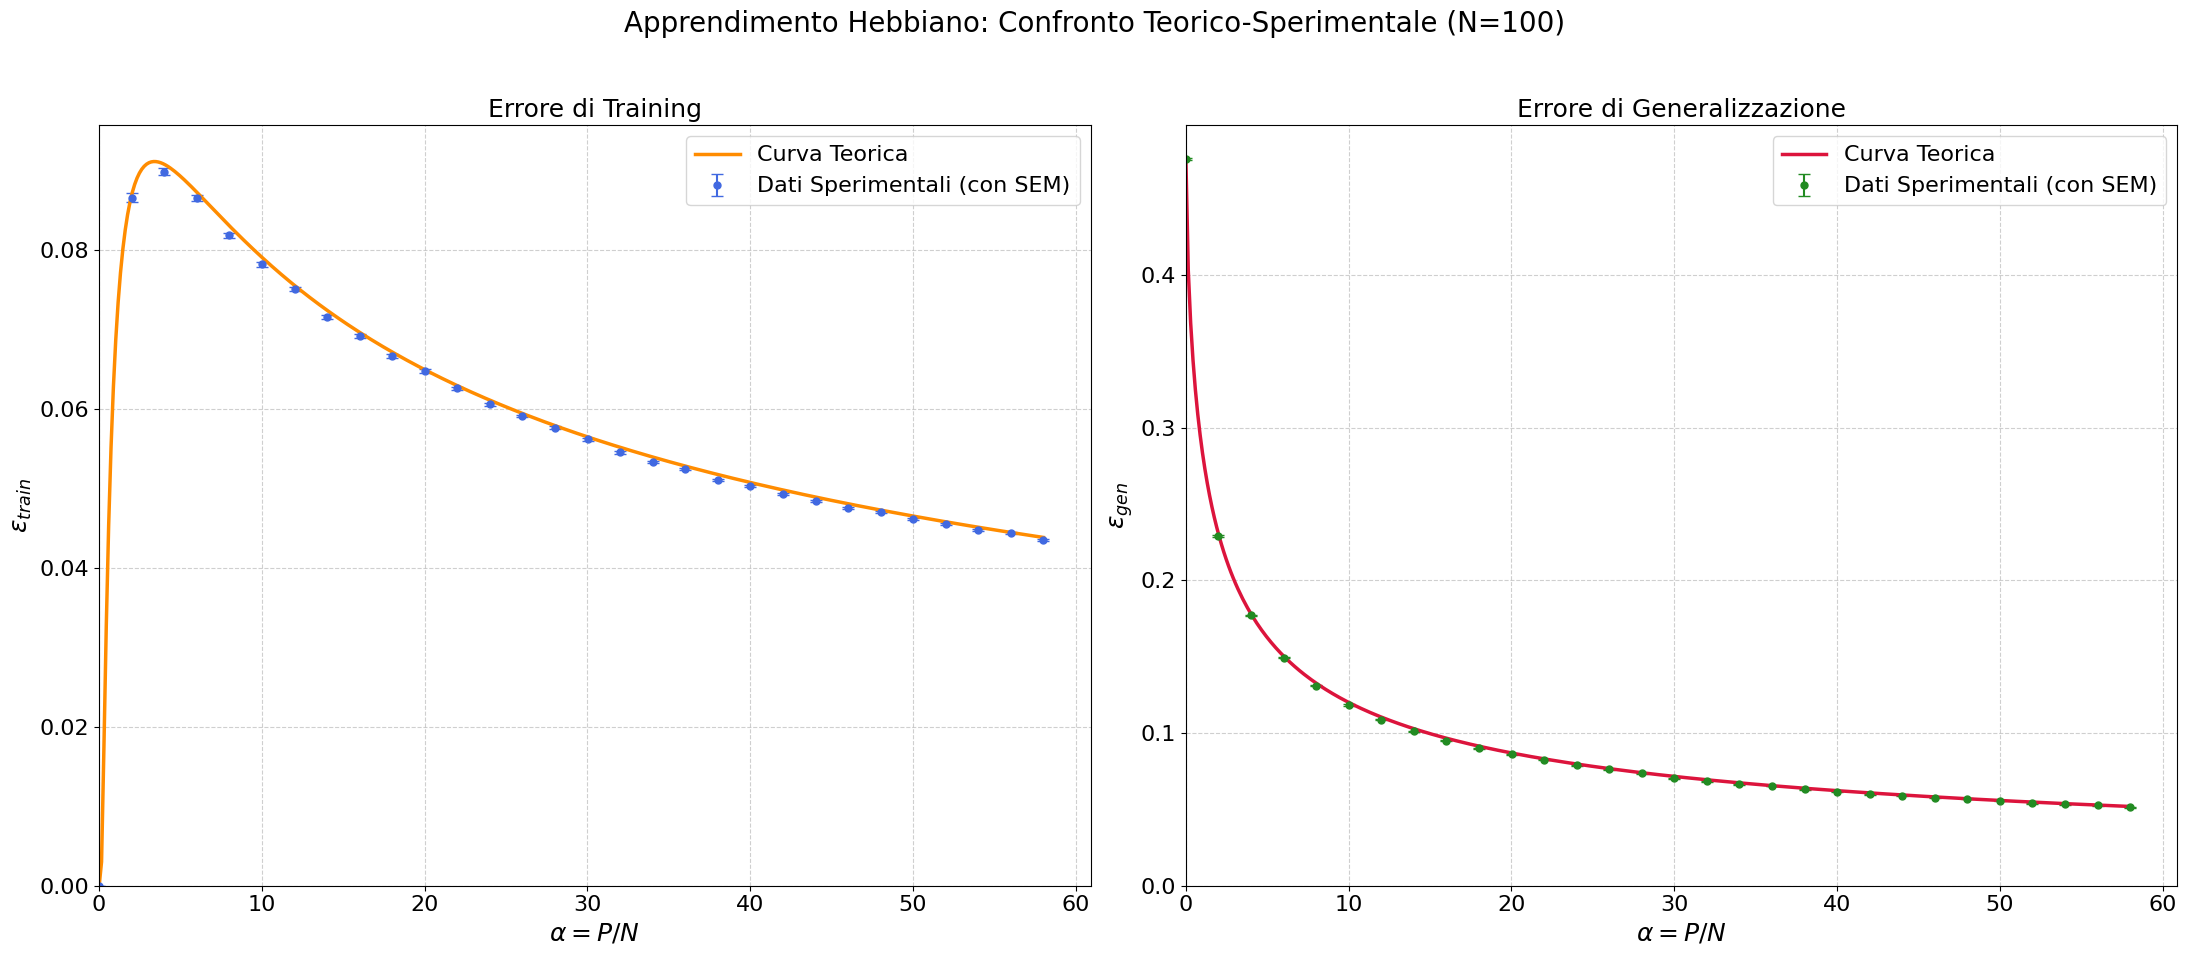

Grafico 2 salvato come 'hebb_error_analysis_N100.png'


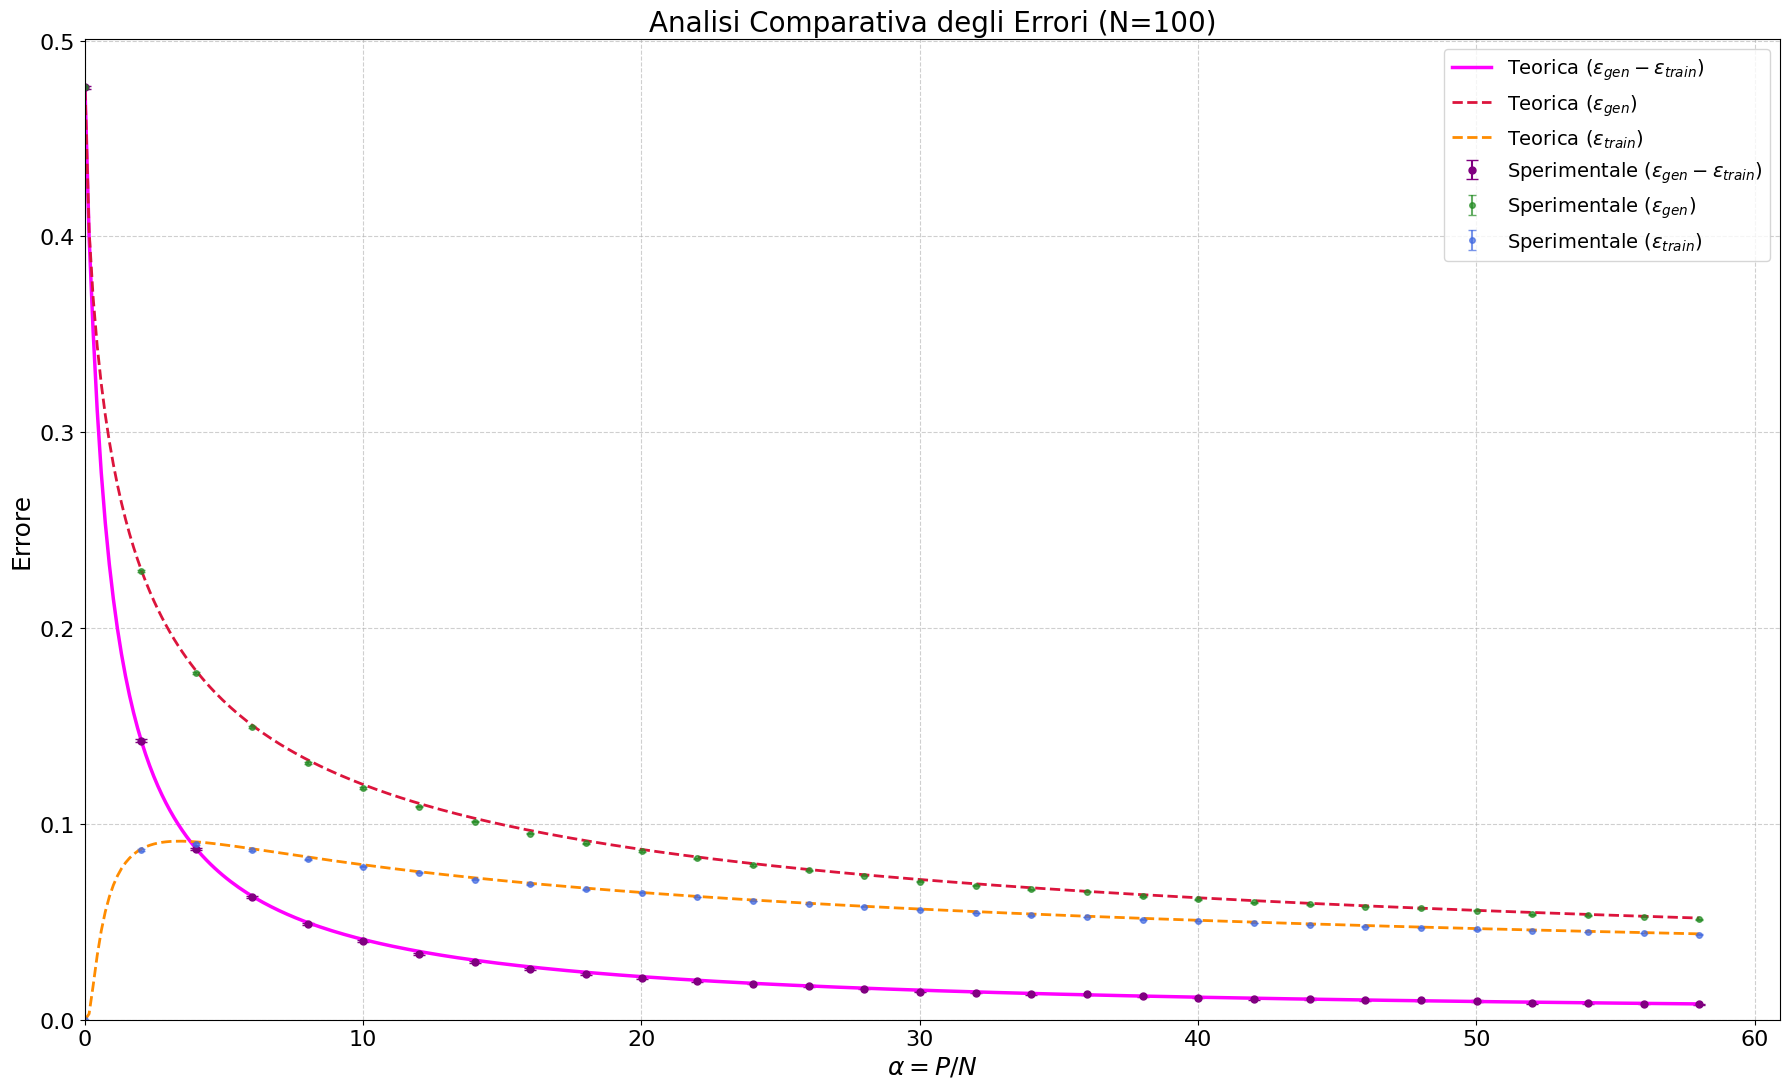

In [89]:
Experiment.plot_hebb_results(experiment_runner, results=final_results)


--- Esecuzione Plot di Confronto Completo ---
Tutti i set di dati necessari sono stati trovati.
Calcolo teorie Annealed, Quenched e Hebb...
--- Calcoli Teorici Completati. Inizio Plotting. ---

Salvataggio figura in: master_comparison_plot_full_with_zero_noise.png


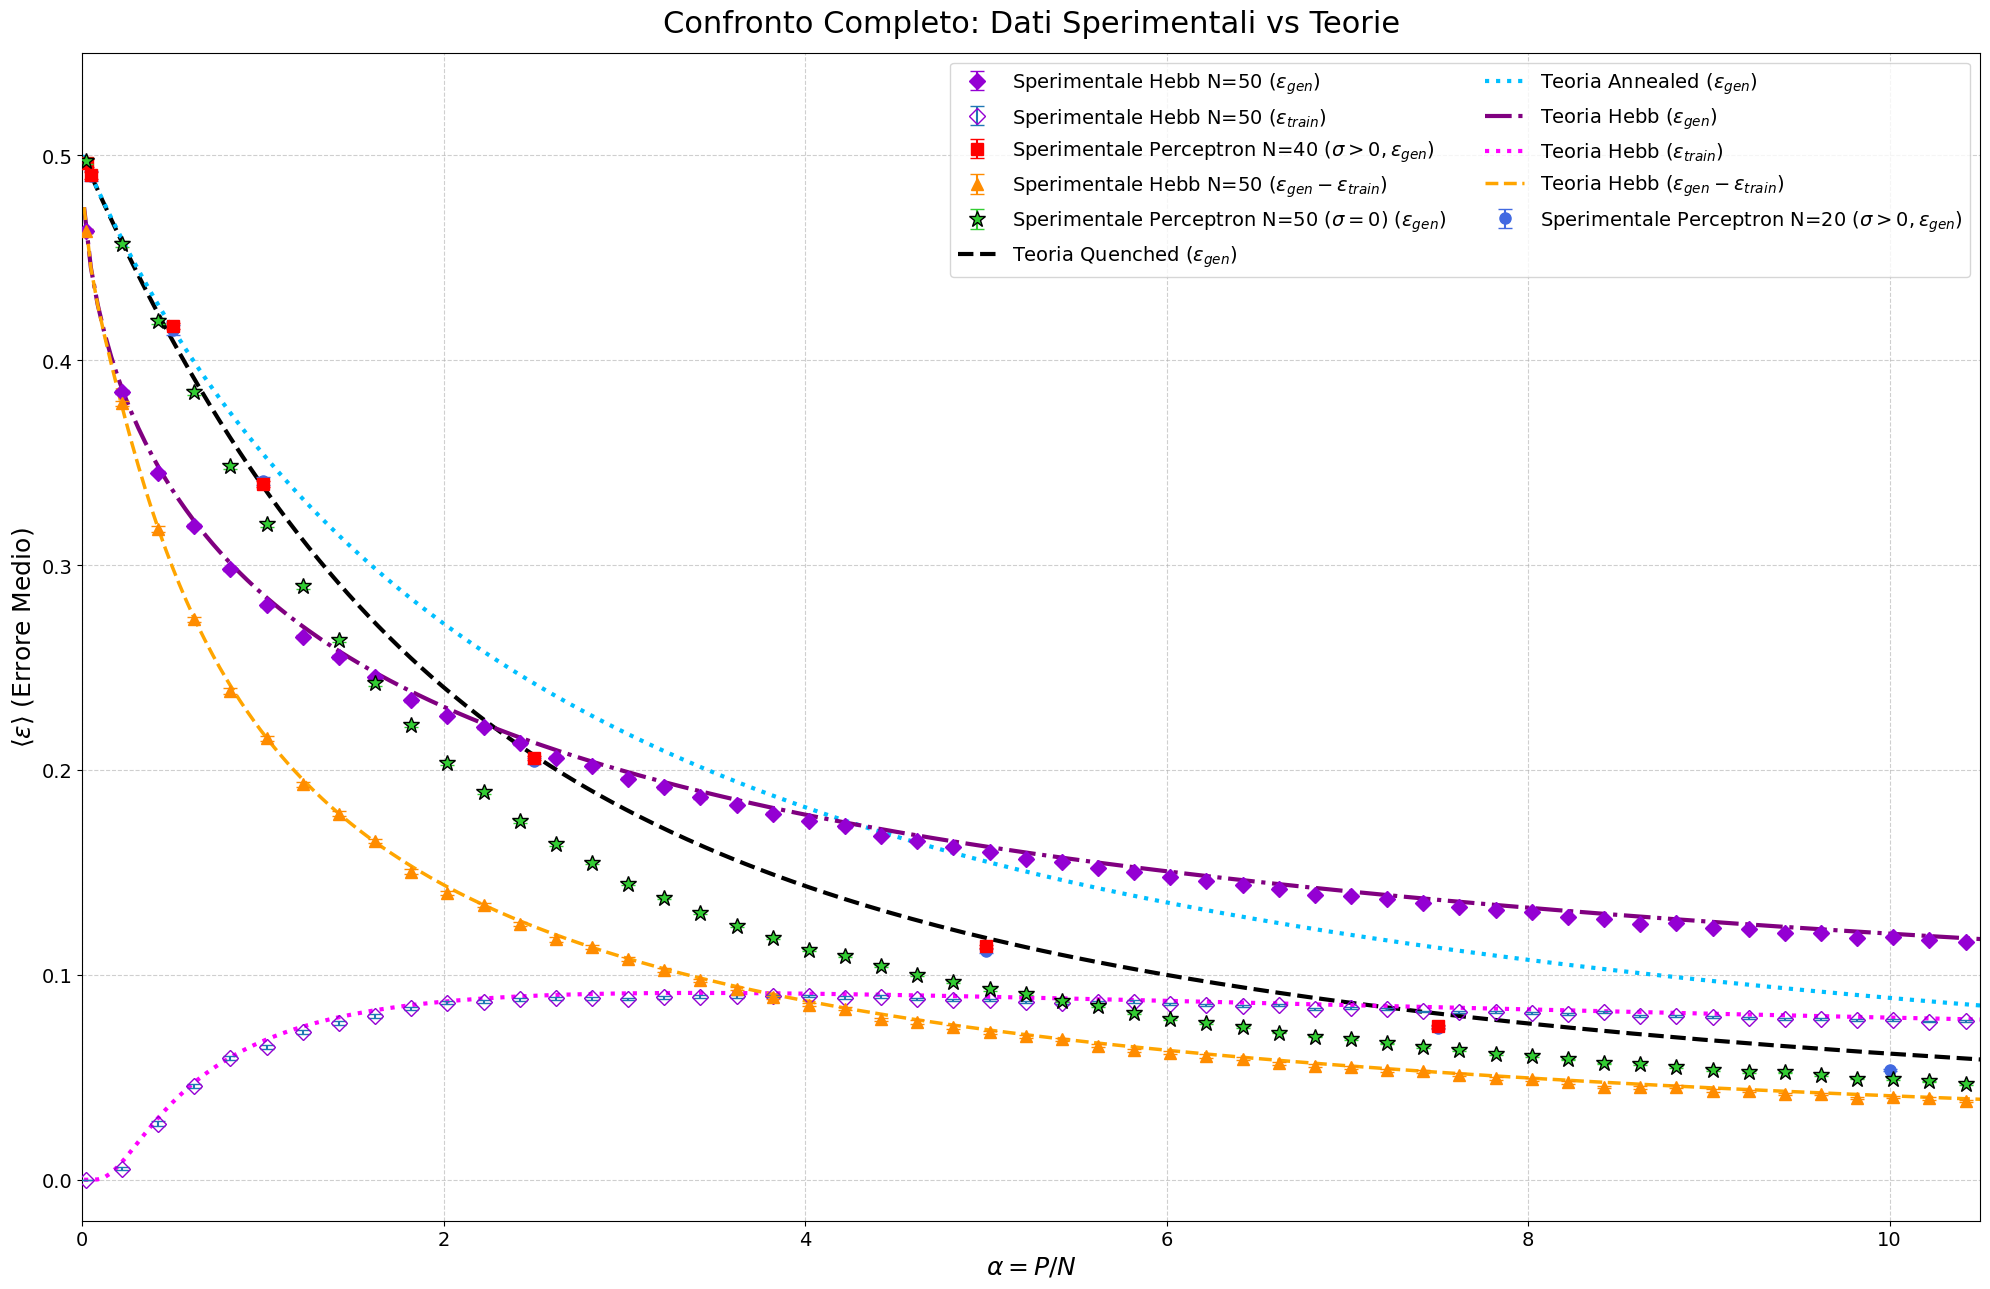

In [32]:
Experiment.plot_advanced_comparison(experiment_runner, results=final_results, save_figure=True)